In [1]:
import numpy as np
import pandas as pd
import sklearn.model_selection
import argparse, os, glob, re, warnings, shutil, pysam, vcf, subprocess
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
import statsmodels.api as sm
from Bio import Seq, SeqIO
import scipy.stats as st
import sys
sys.path.append("../lowAF_variant_calling/scripts")
from epi_utils import *

df_isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/combined_patient_WGS_data.csv")

df_assemblies = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv")
df_ASM_QC = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/hybridASM_QC.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID
        
    if not pd.isnull(row['Lineage']):
        if type(row['Lineage']) == float:
            df_trust_patients.loc[i, 'Lineage'] = str(int(row['Lineage']))
        else:
            df_trust_patients.loc[i, 'Lineage'] = str(row['Lineage'])
     
print(df_trust_patients.Lineage.value_counts())
            
F2_max = 0.03
h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

genomic_data_dir = "/n/data1/hms/dbmi/farhat/rollingDB/genomic_data"

LinToColor_Dict = {"1": "#DF83AC",
                   "2": "#7098CB",
                   "3": "#815D9F",
                   "4": "#E76956",
                  }

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

# remove rRNAs, which are highly conserved. rrs, rrl, and rrf
rRNA_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='stable RNAs' & Feature=='rRNA'").iterrows():
    print(row['Name'])
    rRNA_pos += list(np.arange(row['Start'], row['Stop'] + 1))
    
insertion_seqs_phages_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='insertion seqs and phages'").iterrows():
    insertion_seqs_phages_pos += list(np.arange(row['Start'], row['Stop'] + 1))
    
insertion_seqs_phages_pos = np.unique(insertion_seqs_phages_pos)

Lineage
2      381
4      330
3       48
2,4      6
1        1
2,3      1
Name: count, dtype: int64
rrs
rrl
rrf


In [2]:
model_dir = "../lowAF_variant_calling/variantDetector/unmixed_only"
model_metrics_files = glob.glob(f"{model_dir}/*/classification_metrics.csv")
df_model_metrics = []

for fName in model_metrics_files:
    
    penalty = os.path.basename(os.path.dirname(fName)).split('penalty_')[-1]
    
    model_metrics = pd.read_csv(fName)
    model_metrics['Penalty'] = penalty
    
    df_pred = pd.read_csv(f"{os.path.dirname(fName)}/training_data_with_predictions.csv")
    FP = len(df_pred.query("pred_class==1 & Real==0"))
    FN = len(df_pred.query("pred_class==0 & Real==1"))
    
    model_metrics['FP'] = FP
    model_metrics['FN'] = FN
    
    df_model_metrics.append(model_metrics)
    
df_model_metrics = pd.concat(df_model_metrics)
df_model_metrics


,Thresh,F1,Sens,Spec,Prec,AUC,Penalty,FP,FN
0,0.57,0.973978,0.980050,0.967581,0.967980,0.986306,elasticnet,13,8
0,0.48,0.977833,0.990025,0.965087,0.965937,0.991157,l1,14,4
0,0.49,0.977833,0.990025,0.965087,0.965937,0.991269,l2,14,4
0,0.67,0.977556,0.977556,0.977556,0.977556,0.991424,none,9,9


In [ ]:
df_pred = pd.read_csv(f"{model_dir}/penalty_none/training_data_with_predictions.csv")
df_val_pred = pd.read_csv(f"{model_dir}/penalty_none/validation_data_with_predictions.csv")

In [45]:
len(df_pred), len(df_pred.query("Real==1")), df_pred.pred_class.mean()

(802, 401, 0.5)

In [46]:
len(df_val_pred), len(df_val_pred.query("pred_class==1")), df_val_pred.pred_class.mean()

(2366, 1205, 0.5092983939137785)

In [49]:
df_val_pred.pred_class.sum() + df_pred.Real.sum(), len(df_pred) + len(df_val_pred), (df_val_pred.pred_class.sum() + df_pred.Real.sum()) / (len(df_pred) + len(df_val_pred))

(1606, 3168, 0.5069444444444444)

In [39]:
df_pred.query("pred_class==1 & Real==0")[['SampleID', 'POS', 'REF', 'ALT', 'AF']]

,SampleID,POS,REF,ALT,AF
162,MFS-160,3717219,C,G,0.139073
189,MFS-17,1333669,T,G,0.929688
208,MFS-172,410019,G,A,0.167883
269,MFS-27,4211206,G,A,0.050193
325,MFS-310,4130682,A,G,0.320690
592,MFS-520,1415097,C,G,0.537559
603,MFS-520,4385946,C,T,0.293399
604,MFS-520,4386108,A,G,0.419087
605,MFS-520,4386142,A,G,0.429907


In [17]:
df_pred.query("pred_class==0 & Real==1")[['SampleID', 'POS', 'REF', 'ALT', 'AF']].sort_values('AF')

,SampleID,POS,REF,ALT,AF
232,MFS-2,908064,G,T,0.050000
647,MFS-58,3834658,G,A,0.052147
661,MFS-611,2112499,G,A,0.067729
15,MFS-110,1629722,C,T,0.071146
120,MFS-150,3497927,G,A,0.089835
511,MFS-410,1595145,A,G,0.119205
103,MFS-135,3501681,C,T,0.343891
399,MFS-325,4338594,A,T,0.741433
409,MFS-326,4338594,A,T,0.774704


In [18]:
df_train['NEG_COV_RATIO'] = np.clip(1-df_train['COV_RATIO'], 0, None)
df_train['POS_COV_RATIO'] = np.clip(df_train['COV_RATIO']-1, 0, None)

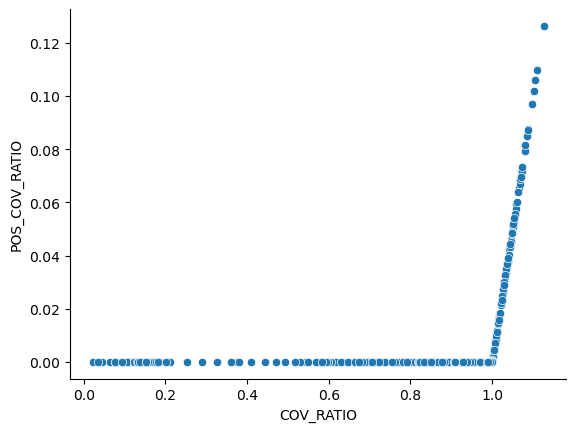

In [19]:
sns.scatterplot(data=df_train,
                x='COV_RATIO',
                y='POS_COV_RATIO'
               )
sns.despine()

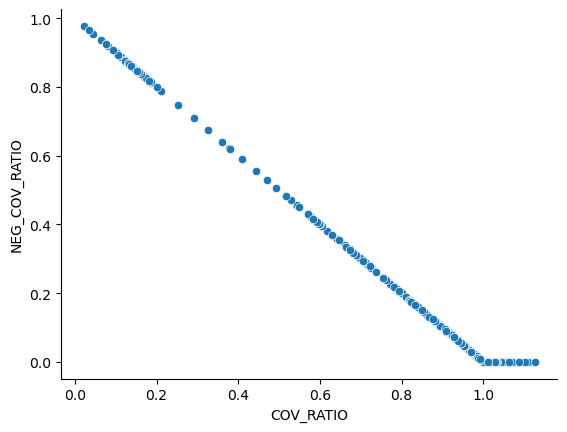

In [20]:
sns.scatterplot(data=df_train,
                x='COV_RATIO',
                y='NEG_COV_RATIO'
               )

sns.despine()

In [21]:
min_val = df_train.COV_RATIO.min()

In [22]:
df_train.query("COV_RATIO==@min_val")[['SampleID', 'DP', 'AO', 'SAF', 'SAR', 'POS', 'REF', 'ALT', 'Real', 'VariantSupportMedianIndex']]

,SampleID,DP,AO,SAF,SAR,POS,REF,ALT,Real,VariantSupportMedianIndex
217,MFS-173,6,5,2,3,2535432,C,A,0,0.007874


# False positive and negatives when benchmarking using hybrid assemblies

In [3]:
confusion_matrix_files = glob.glob(f"{personal_ref_dir}/*/lowAF_comparison/confusion_matrix.csv")

df_confusion_matrix = []

for fName in confusion_matrix_files:
    
    df = pd.read_csv(fName)
    
    df_H37Rv = df.loc[(~pd.isnull(df['H37Rv_POS'])) & (pd.isnull(df['POS']))]
    df_personal = df.loc[(~pd.isnull(df['POS'])) & (pd.isnull(df['H37Rv_POS']))]
    df_both = df.dropna(subset=['POS', 'H37Rv_POS'], how='any', axis=0)
    
    if len(df_both) > 0:
        df = df_both.query("H37Rv_REF.str.len() == H37Rv_ALT.str.len()")
    
    # exclude indels. Need to do it this way because of NaNs
    if len(df_H37Rv) > 0:
        df = pd.concat([df, df_H37Rv.query("H37Rv_REF.str.len() == H37Rv_ALT.str.len()")])
        
    if len(df_personal) > 0:
        df = pd.concat([df, df_personal.query("REF.str.len() == ALT.str.len()")])
    
    df_ground_truth = pd.read_csv(fName.replace('confusion_matrix.csv', 'ground_truth.csv'))
    df_ground_truth['POS'] = df_ground_truth['POS'].astype(float)
    
    df[['REF', 'ALT']] = df[['REF', 'ALT']].astype(object)
    
    # add the other alignment information to it. It's only in ground_truth.csv, not in confusion_matrix.csv
    df = df.merge(df_ground_truth, on=['POS', 'REF', 'ALT'], how='left')
    
    df['SampleID'] = os.path.basename(os.path.dirname(os.path.dirname(fName)))
    df_confusion_matrix.append(df)
    
# ground truth files include AFs down to 2-98% now, but we're benchmarking 5% minimum
# df_confusion_matrix = pd.concat(df_confusion_matrix).query("~(POS >= 2338065 & POS <= 2340874) & ~(AF < 0.05 | AF > 0.95)")
df_confusion_matrix = pd.concat(df_confusion_matrix).query("~(AF < 0.05 | AF > 0.95)")

df_confusion_matrix = df_confusion_matrix.merge(df_trust_patients[['SampleID', 'F2']])

df_confusion_matrix['Region'] = df_confusion_matrix['POS'].map(h37Rv_coords_dict)

df_mixed_confusion_matrix = df_confusion_matrix.query("F2 > @F2_max")

df_confusion_matrix = df_confusion_matrix.query("F2 <= @F2_max")

In [9]:
df_confusion_matrix.Result.value_counts()

Result
FP    1093
TP     402
Name: count, dtype: int64

In [8]:
df_mixed_confusion_matrix.Result.value_counts()

Result
TP    7294
FP      72
FN      21
Name: count, dtype: int64

# 0. Rv3433c GC Content because the coverage drops off slowly, rather than abruptly

In [162]:
Rv3433c_seq = str(h37Rv_seq.seq[3851792-1:3853213])
print(len(Rv3433c_seq))

base_counts = dict(zip(np.unique(list(Rv3433c_seq), return_counts=True)[0], np.unique(list(Rv3433c_seq), return_counts=True)[1]))

(base_counts['C'] + base_counts['G']) / (np.array(list(base_counts.values())).sum())

1422


0.7475386779184248

In [163]:
base_counts = dict(zip(np.unique(list(h37Rv_seq), return_counts=True)[0], np.unique(list(h37Rv_seq), return_counts=True)[1]))

(base_counts['C'] + base_counts['G']) / (np.array(list(base_counts.values())).sum())

0.6561466628826449

# 1. Coverage Statistics and Lengths of the Hybrid Assemblies

In [17]:
# drop duplicates because some ASMs have been matched with multiple Illumina samples for the purposes of making the ground truth set
df_assemblies_QC = df_assemblies.merge(df_ASM_QC, on=['ASM', 'PacBio_FQ_PATH']).drop_duplicates(subset='ASM')

assert len(df_assemblies_QC.query("Flye_Coll2014 != Flye_PP_Coll2014")) == 0
assert len(df_assemblies_QC.query("Flye_Coll2014 != Illumina_Coll2014")) == 0

df_assemblies_QC['Lineage'] = df_assemblies_QC['Flye_PP_Coll2014'].str.split('.').str[0]

df_assemblies_QC.to_csv("../supplement/hybrid_assembly_statistics.csv", index=False)

assert len(df_assemblies_QC.query("numContigs > 1 | circContigLength < 4300000")) == 0

len(df_assemblies_QC)

154

In [108]:
tbtyper_culture = pd.read_csv("../lowAF_variant_calling/data/tbtyper_culture.csv")

In [109]:
tbtyper_culture.query("SampleID.str.contains('MFS-401')")

,SampleID,mix_phylotypes,mix_props,n_phy,defaultParams
262,MFS-401,4.3.2.1,1.0,1,1


In [110]:
df_ASM_QC_tbtyper = df_ASM_QC.merge(tbtyper_culture, left_on=['Illumina_ID'], right_on='SampleID')

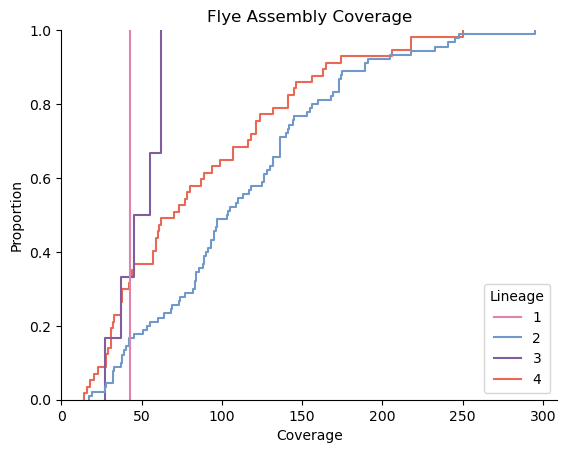

In [13]:
ax = sns.ecdfplot(
    data=df_assemblies_QC,
    x='Flye_Cov',
    hue='Lineage',
    palette=LinToColor_Dict,
    hue_order=np.sort(df_assemblies_QC['Lineage'].unique())
)

# Get the existing legend created by seaborn
sns.move_legend(ax, "lower right")

plt.title("Flye Assembly Coverage")
plt.xlabel('Coverage')

sns.despine()
plt.savefig("./figures/flye_coverage.svg", bbox_inches='tight')

In [14]:
df_assemblies_QC.query("Lineage=='1'")

,SampleID,ASM,PacBio_FQ_PATH,ASM_SampleID,pid,Original_ID,numContigs,circContigLength,Flye_Cov,Flye_Coll2014,Flye_PP_Coll2014,NumPilonChanges,PacBio_ID,Illumina_ID,Illumina_F2,Illumina_Coll2014,Lineage
24,MFS-520,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-520,T0017,S0017-01,1,4429510.0,43,1.1.2,1.1.2,0,MFS-520,MFS-520,0.019246,1.1.2,1


# 2. Selecting the F2 threshold: Show number of low-AF variants (before LMM) vs. F2

In [2]:
all_samples = os.listdir(H37Rv_ref_dir)
len(all_samples)

767

In [3]:
ground_truth_samples = os.listdir(personal_ref_dir)
len(ground_truth_samples)

179

In [4]:
df_lowAF_SNPs = []

for i, sample in enumerate(all_samples):
    
    df = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/lowAF_SNPs.csv")

    df = df.query("AF >= 0.05 & AF <= 0.95 & POS not in @insertion_seqs_phages_pos & POS not in @rRNA_pos")
    df['SampleID'] = sample
    
    df_lowAF_SNPs.append(df.query("REF.str.len() == ALT.str.len()"))

df_lowAF_SNPs = pd.concat(df_lowAF_SNPs).drop_duplicates(['SampleID', 'POS', 'REF', 'ALT'], keep='last').merge(df_trust_patients[['pid', 'SampleID', 'F2', 'Lineage', 'Coll2014']], how='left')
df_lowAF_SNPs['Region'] = df_lowAF_SNPs['POS'].map(h37Rv_coords_dict)

# exclude Rv2081c-Rv2082
# df_lowAF_SNPs = df_lowAF_SNPs.query("~(POS >= 2338065 & POS <= 2340874)")

# require minimum base quality of bases supporting the variant
df_lowAF_SNPs = df_lowAF_SNPs.query("Mean_BQ_ALT_allele >= 20")

df_lowAF_SNPs_summary = pd.DataFrame(df_lowAF_SNPs.groupby(['pid', 'SampleID', 'F2'])['POS'].count().reset_index().rename(columns={'POS': 'NumSNPs'}))

df_lowAF_SNPs_summary = pd.concat([df_lowAF_SNPs_summary,
                                   df_trust_patients.dropna(subset='Lineage').query("SampleID not in @df_lowAF_SNPs_summary.SampleID")[['pid', 'SampleID', 'F2', 'Lineage', 'Coll2014']]
                                ])

df_lowAF_SNPs_summary['NumSNPs'] = df_lowAF_SNPs_summary['NumSNPs'].fillna(0).astype(int)

In [19]:
unmixed_samples = df_lowAF_SNPs_summary.query("F2 <= @F2_max").SampleID.unique()

In [20]:
df_lowAF_SNPs_summary.query("F2 <= @F2_max")['NumSNPs'].sum()

3620

In [5]:
df_tbtyper = pd.read_csv("~/MtbLongitudinalDiversity/TBtypeR/culture_TBtypeR_results.csv")
df_tbtyper['SampleID'] = df_tbtyper['sample_id'].str.split('.').str[0]

df_tbtyper['mix_phylotypes'] = df_tbtyper.groupby('SampleID')['mix_phylotype'].transform(lambda x: ','.join(x))
df_tbtyper['mix_props'] = df_tbtyper.groupby('SampleID')['mix_prop'].transform(lambda x: ','.join(np.array(x).astype(str)))

df_tbtyper = df_tbtyper.drop_duplicates(subset=['SampleID', 'n_phy']).reset_index(drop=True)

In [6]:
for i, row in df_tbtyper.query("n_phy > 1").iterrows():
    
    lineages = row['mix_phylotypes'].split(',')
    
    primary_lineages = []
    
    for lineage in lineages:
        primary_lineages.append(lineage[0])
        
    if len(np.unique(primary_lineages)) > 1:
        df_tbtyper.loc[i, 'Multiple_Lineages'] = 1
    else:
        df_tbtyper.loc[i, 'Multiple_Lineages'] = 0
        
df_lowAF_SNPs_summary = df_lowAF_SNPs_summary.merge(df_tbtyper[['SampleID', 'Multiple_Lineages']])
df_lowAF_SNPs_summary['Multiple_Lineages'] = df_lowAF_SNPs_summary['Multiple_Lineages'].fillna(2).astype(int)

In [7]:
df_tbtyper.Multiple_Lineages.value_counts(dropna=False)

Multiple_Lineages
NaN    732
1.0     27
0.0      8
Name: count, dtype: int64

In [19]:
# samples with mixed sublineages that are the same primary lineage have significantly fewer
# unfixed SNVs than samples with mixed sublineages that are different primary lineages
# this makes sense because the latter are more likely to have the same lineage-determining
# variants higher up in the lineage classification tree
# i.e. they both have the L2 and L2.2 variants, but they differ deeper in the tree
st.ttest_ind(df_lowAF_SNPs_summary.query("Multiple_Lineages==0").NumSNPs,
             df_lowAF_SNPs_summary.query("Multiple_Lineages==1").NumSNPs,
             equal_var=False,
             alternative='less'
            )

TtestResult(statistic=-2.765624075576221, pvalue=0.006551939354372524, df=17.241399065874358)

In [20]:
st.ttest_ind(df_lowAF_SNPs_summary.query("Multiple_Lineages==2").NumSNPs,
             df_lowAF_SNPs_summary.query("Multiple_Lineages==0").NumSNPs,
             equal_var=False,
             alternative='less'
            )

TtestResult(statistic=-3.4109191182861576, pvalue=0.005636834898118241, df=7.000021310533899)

In [21]:
st.ttest_ind(df_lowAF_SNPs_summary.query("Multiple_Lineages==2").NumSNPs,
             df_lowAF_SNPs_summary.query("Multiple_Lineages==1").NumSNPs,
             equal_var=False,
             alternative='less'
            )

TtestResult(statistic=-8.592434811671332, pvalue=2.257861363201542e-09, df=26.000120203912566)

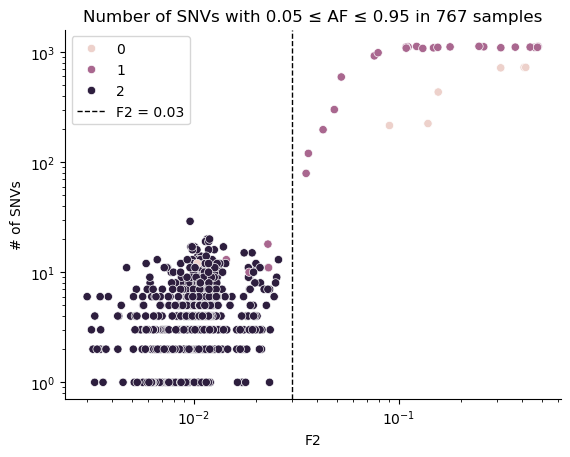

In [12]:
sns.scatterplot(data=df_lowAF_SNPs_summary,
                x='F2',
                y='NumSNPs',
                hue='Multiple_Lineages'
               )

plt.ylabel('# of SNVs')
plt.title(f'Number of SNVs with 0.05 ≤ AF ≤ 0.95 in {df_lowAF_SNPs_summary.SampleID.nunique()} samples')

plt.xscale('log')
plt.yscale('log')

plt.axvline(F2_max, linestyle='--', color='black', linewidth=1, label=f'F2 = {F2_max}')
plt.legend()

sns.despine()

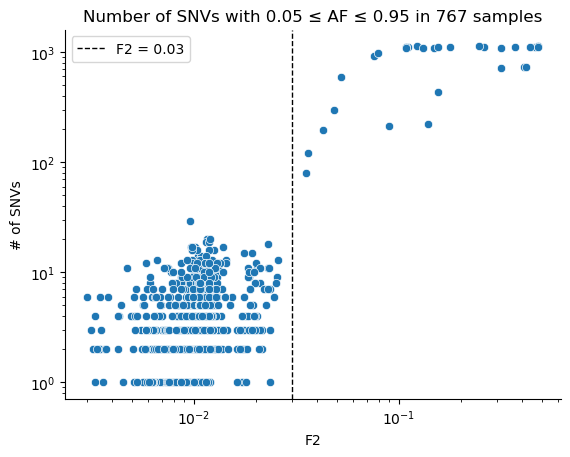

In [56]:
sns.scatterplot(data=df_lowAF_SNPs_summary.merge(df_tbtyper[['SampleID', 'Multiple_Lineages']]),
                x='F2',
                y='NumSNPs',
                hue='Multiple_Lineages'
               )

plt.ylabel('# of SNVs')
plt.title(f'Number of SNVs with 0.05 ≤ AF ≤ 0.95 in {df_lowAF_SNPs_summary.SampleID.nunique()} samples')

plt.xscale('log')
plt.yscale('log')

plt.axvline(F2_max, linestyle='--', color='black', linewidth=1, label=f'F2 = {F2_max}')
plt.legend()

sns.despine()
# plt.savefig("./figures/lowAF_SNVs_vs_F2_prefilt.svg", bbox_inches='tight')

In [57]:
df_lowAF_SNPs.query("F2 <= @F2_max").Region.value_counts().head(10)

Region
Rv2082      394
Rv2319c     368
iniB        237
uspC        234
NC_2395      81
fadD11.1     76
mmpS1        68
Rv2081c      58
Rv1637c      47
sugI         44
Name: count, dtype: int64

In [58]:
len(df_lowAF_SNPs.query("F2 <= @F2_max"))

3620

In [59]:
df_lowAF_SNPs.query("SampleID in @ground_truth_samples & SampleID in @unmixed_samples & Region=='Rv2082'").shape

(56, 75)

# 3. Number of low-AF SNVs per Hybrid Assembly

In [40]:
df_ground_truth_lowAF_SNPs = []
df_ground_truth_lowAF_indels = []

for i, sample in enumerate(ground_truth_samples):
    
    df = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/ground_truth.csv")

    df = df.query("AF >= 0.05 & AF <= 0.95 & POS not in @insertion_seqs_phages_pos & POS not in @rRNA_pos")
    df['SampleID'] = sample
    
    df_ground_truth_lowAF_SNPs.append(df.query("REF.str.len() == ALT.str.len()"))
    df_ground_truth_lowAF_indels.append(df.query("REF.str.len() != ALT.str.len()"))

df_ground_truth_lowAF_SNPs = pd.concat(df_ground_truth_lowAF_SNPs).drop_duplicates(['SampleID', 'POS', 'REF', 'ALT'], keep='last').merge(df_trust_patients[['pid', 'SampleID', 'F2']], how='left')
df_ground_truth_lowAF_SNPs['SameSample'] = df_ground_truth_lowAF_SNPs['SampleID'].isin(df_assemblies_QC.Illumina_ID.values).astype(int)
df_ground_truth_lowAF_SNPs['Region'] = df_ground_truth_lowAF_SNPs['POS'].map(h37Rv_coords_dict)

df_ground_truth_lowAF_SNPs_summary = pd.DataFrame(df_ground_truth_lowAF_SNPs.groupby(['pid', 'SampleID', 'F2'])['POS'].count().reset_index().rename(columns={'POS': 'NumSNPs'}))

df_ground_truth_lowAF_SNPs_summary = pd.concat([df_ground_truth_lowAF_SNPs_summary,
                                              df_trust_patients.query("SampleID in @ground_truth_samples & SampleID not in @df_ground_truth_lowAF_SNPs_summary.SampleID")[['pid', 'SampleID', 'F2']]
                                             ])

df_ground_truth_lowAF_SNPs_summary['NumSNPs'] = df_ground_truth_lowAF_SNPs_summary['NumSNPs'].fillna(0).astype(int)

df_ground_truth_lowAF_SNPs_summary['SameSample'] = df_ground_truth_lowAF_SNPs_summary['SampleID'].isin(df_assemblies_QC.Illumina_ID.values).astype(int)

df_ground_truth_lowAF_indels = pd.concat(df_ground_truth_lowAF_indels).drop_duplicates(['SampleID', 'POS', 'REF', 'ALT'], keep='last').merge(df_trust_patients[['pid', 'SampleID', 'F2']], how='left')
df_ground_truth_lowAF_indels_summary = pd.DataFrame(df_ground_truth_lowAF_indels.groupby(['pid', 'SampleID', 'F2'])['POS'].count().reset_index().rename(columns={'POS': 'NumIndels'}))

df_ground_truth_lowAF_indels_summary = pd.concat([df_ground_truth_lowAF_indels_summary,
                                                  df_trust_patients.query("SampleID in @ground_truth_samples & SampleID not in @df_ground_truth_lowAF_SNPs_summary.SampleID")[['pid', 'SampleID', 'F2']]
                                                 ])

df_ground_truth_lowAF_indels_summary['NumIndels'] = df_ground_truth_lowAF_indels_summary['NumIndels'].fillna(0).astype(int)

In [9]:
# add 1 to the sugI count for the sugI variant that wasn't transferred over
pd.DataFrame(df_ground_truth_lowAF_SNPs.query("F2 <= @F2_max").Region.value_counts()).query("count >= 3")['count'].sum()

53

In [10]:
df_ground_truth_lowAF_SNPs.pid.nunique()

94

In [11]:
# add 1 for the sugI variant that wasn't transferred over
len(df_ground_truth_lowAF_SNPs.query("F2 <= @F2_max"))

400

In [15]:
df_ground_truth_lowAF_SNPs.query("F2 <= @F2_max").Region.value_counts().head(10)

Region
sugI       8
subI       7
Rv3220c    6
devS       5
katG       4
NC_1391    4
PPE50      4
virS       3
phoR       3
NC_9       3
Name: count, dtype: int64

In [ ]:
df_trust_patients.query("SampleID in @ground_truth_samples & F2 <= @F2_max").Lineage.value_counts()

In [ ]:
len(df_trust_patients.query("SampleID in @ground_truth_samples & F2 <= @F2_max"))

In [ ]:
len(df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max").query("NumSNPs==0")) / len(df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max"))

In [ ]:
df_ground_truth_lowAF_SNPs_summary.SameSample.value_counts()

In [ ]:
# NC_9 = between Rv0010c and Rv0011c. dnaA binds there
# NC_2982 = between whiB6 and Rv3863
# NC_1391 = Rv1794-eccD5
pd.DataFrame(df_ground_truth_lowAF_SNPs.query("F2 <= @F2_max").Region.value_counts()).query("count > 2")

400 total SNVs


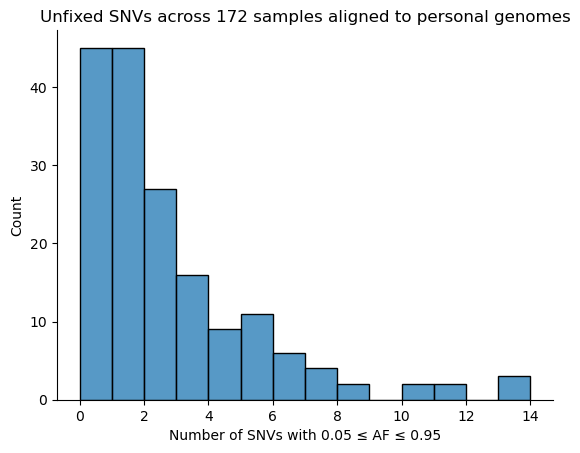

In [70]:
df_plot = df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max")

sns.histplot(data=df_plot,
             x='NumSNPs',
             bins=np.arange(df_plot.NumSNPs.min(), df_plot.NumSNPs.max() + 1),
            )

print(f"{df_plot.NumSNPs.sum()} total SNVs")

plt.title(f"Unfixed SNVs across {df_plot.SampleID.nunique()} samples aligned to personal genomes")
plt.xlabel('Number of SNVs with 0.05 ≤ AF ≤ 0.95')

sns.despine()
plt.savefig("./figures/personal_genome_lowAF_counts_dist.svg", bbox_inches='tight')

In [21]:
# check that using the same sample as the personal reference genome vs. using a different sample BUT STILL FROM THE SAME PERSON
# are not significantly different
st.ks_2samp(df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max")['NumSNPs'],
            df_ground_truth_lowAF_SNPs_summary.query("SameSample==1 & F2 <= @F2_max")['NumSNPs'],
            alternative='two-sided'
           )

KstestResult(statistic=0.018206854345165238, pvalue=0.999999999999997, statistic_location=0, statistic_sign=1)

In [22]:
min_val = df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max").NumSNPs.min()
max_val = df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max").NumSNPs.max()
median_val = df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max").NumSNPs.median()
mean_val = df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max").NumSNPs.mean()

print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median_val}")
print(f"Mean: {mean_val}")

Min: 0
Max: 14
Median: 1.0
Mean: 2.3255813953488373


# 4. Compare number of unfixed SNVs between ground truth and H37Rv alignments

866 total SNVs


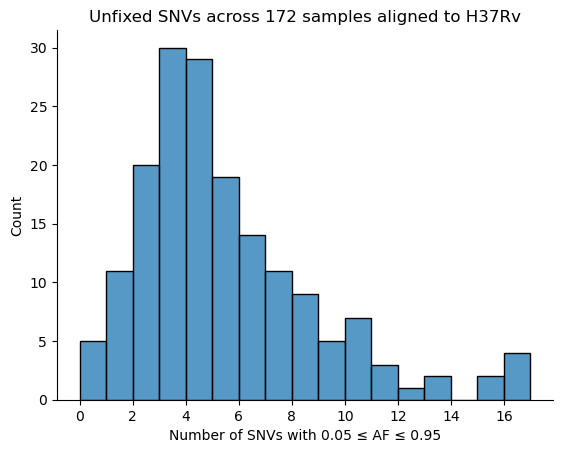

In [25]:
df_plot = df_lowAF_SNPs_summary.query("F2 <= @F2_max & SampleID in @df_ground_truth_lowAF_SNPs_summary.SampleID")
              
sns.histplot(data=df_plot,
             x='NumSNPs',
             bins=np.arange(df_plot.NumSNPs.min(), df_plot.NumSNPs.max() +1),
            )

print(f"{df_plot.NumSNPs.sum()} total SNVs")
plt.title(f"Unfixed SNVs across {df_plot.SampleID.nunique()} samples aligned to H37Rv")
plt.xlabel('Number of SNVs with 0.05 ≤ AF ≤ 0.95')

ax = plt.gca()

# Force integer ticks
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

sns.despine()
plt.savefig("./figures/H37Rv_lowAF_counts_initial_dist_ground_truth.svg", bbox_inches='tight')

In [26]:
df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max").rename(columns={'NumSNPs': 'Before'})

,pid,SampleID,F2,NumSNPs,SameSample
0,T0001,MFS-331,0.010162,5,1
1,T0004,MFS-1,0.011212,1,1
2,T0004,MFS-2,0.010401,2,1
3,T0007,MFS-3,0.008362,1,1
4,T0008,MFS-4,0.007025,7,1
...,...,...,...,...,...
754,T0317,MFS-319,0.011743,0,1
764,T0285,MFS-327,0.010527,0,1
766,T0321,MFS-330,0.012087,0,1
767,T0321,MFS-320,0.012366,0,1


In [27]:
df_lowAF_SNPs_summary.query("F2 <= @F2_max & SampleID in @df_ground_truth_lowAF_SNPs_summary.SampleID")

,pid,SampleID,F2,NumSNPs,Lineage,Coll2014
0,T0001,MFS-331,0.010162,6,NaN,NaN
5,T0004,MFS-1,0.011212,4,NaN,NaN
6,T0004,MFS-2,0.010401,5,NaN,NaN
9,T0007,MFS-3,0.008362,5,NaN,NaN
10,T0008,MFS-4,0.007025,7,NaN,NaN
...,...,...,...,...,...,...
38,T0192,MFS-877,0.007714,0,4,4.1.1.1
435,T0401,MFS-675,0.008097,0,4,4.3.3
583,T0186,MFS-104,0.009906,0,4,4.8
584,T0123,MFS-60,0.009030,0,4,4.4.1.1


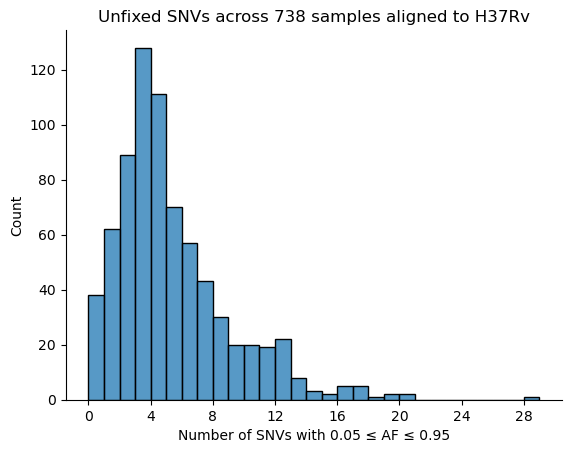

In [74]:
df_plot = df_lowAF_SNPs_summary.query("F2 <= @F2_max")# & SampleID in @df_ground_truth_lowAF_SNPs_summary.SampleID")
              
sns.histplot(data=df_plot,
             x='NumSNPs',
             bins=np.arange(df_plot.NumSNPs.min(), df_plot.NumSNPs.max() +1),
            )

plt.title(f"Unfixed SNVs across {df_plot.SampleID.nunique()} samples aligned to H37Rv")
plt.xlabel('Number of SNVs with 0.05 ≤ AF ≤ 0.95')

ax = plt.gca()

# Force integer ticks
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

sns.despine()
plt.savefig("./figures/H37Rv_lowAF_counts_initial_dist.svg", bbox_inches='tight')

In [75]:
df_lowAF_SNPs.SampleID.nunique()

729

In [81]:
min_val = df_lowAF_SNPs_summary.query("F2 <= @F2_max & SampleID in @ground_truth_samples").NumSNPs.min()
max_val = df_lowAF_SNPs_summary.query("F2 <= @F2_max & SampleID in @ground_truth_samples").NumSNPs.max()
median_val = df_lowAF_SNPs_summary.query("F2 <= @F2_max & SampleID in @ground_truth_samples").NumSNPs.median()
mean_val = df_lowAF_SNPs_summary.query("F2 <= @F2_max & SampleID in @ground_truth_samples").NumSNPs.mean()

print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median_val}")
print(f"Mean: {mean_val}")

Min: 0
Max: 17
Median: 4.0
Mean: 5.034883720930233


In [77]:
df_lowAF_SNPs_summary.query("F2 <= @F2_max").NumSNPs.sum()

3620

In [78]:
df_compare_ground_truth_H37Rv = df_ground_truth_lowAF_SNPs_summary.merge(df_lowAF_SNPs_summary.query("F2 <= @F2_max").rename(columns={'NumSNPs': 'NumSNPs_H37Rv', 'NumIndels': 'NumIndels_H37Rv'}), on=['SampleID', 'pid', 'F2'])

df_compare_ground_truth_H37Rv['Difference'] = df_compare_ground_truth_H37Rv['NumSNPs_H37Rv'] - df_compare_ground_truth_H37Rv['NumSNPs']

min_val = df_compare_ground_truth_H37Rv.Difference.min()
max_val = df_compare_ground_truth_H37Rv.Difference.max()
median_val = df_compare_ground_truth_H37Rv.Difference.median()
mean_val = df_compare_ground_truth_H37Rv.Difference.mean()

print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median_val}")
print(f"Mean: {mean_val}")

Min: 0
Max: 14
Median: 3.0
Mean: 2.7093023255813953


In [80]:
st.wilcoxon(df_compare_ground_truth_H37Rv['NumSNPs'],
            df_compare_ground_truth_H37Rv['NumSNPs_H37Rv'],
            alternative='less'
           )

WilcoxonResult(statistic=0.0, pvalue=3.668762486456811e-28)

# 5. Number of SNVs before and after logistic regression model

In [3]:
def read_in_process_variants(model_dir, df_pids, AF_thresh=0.95):
    
    df_fixed_variants = pd.read_csv(f"{os.path.dirname(model_dir)}/fixed_variants.csv.gz", compression='gzip')
    
    # contains Real or not for the samples with a personal genome
    df_train_variants = pd.read_csv(f"{model_dir}/training_data_with_predictions.csv").query("Real == 1")

    # because of the discordant reads at the end of the linear reference genome, which are not actually discordant, it's just because the circular genome was linearized
    # the binary classifier will predict some low frequency variants at the ends as false because of all the discordantly paired reads there
    # this means that variant upstream of the first position and downstream of the last position can be erroneously flagged as not real
    first_pos = df_train_variants.query("Real==1").POS.min()
    last_pos = df_train_variants.query("Real==1").POS.max()

    # all other samples
    df_val_variants = pd.read_csv(f"{model_dir}/validation_data_with_predictions.csv")
    
    df_val_variants.loc[df_val_variants['POS']==4338594, 'pred_class'] = 1
    
    # keep all unfixed variants outside of the positional bounds in the training set
    # This is because the circular genome has been linearized for variant calling, so there are lots of discordantly paired reads at the ends
    # but they're not real. If the genome had been circular during alignment, they wouldn't be discordant. So these positions are usually real unfixed SNVs
    df_val_variants.loc[(df_val_variants['POS'] < first_pos) | df_val_variants['POS'] > last_pos, 'pred_class'] = 1
    
    # exclude fixed SNP sites that had a low quality low frequency variant. Exclude these from the fixed counts too
    for pid in df_val_variants.pid.unique():

        false_lowAF_variant_sites = df_val_variants.query("pid==@pid & pred_class==0").POS.values

        if len(false_lowAF_variant_sites) > 0:
            df_fixed_variants = df_fixed_variants.query("~(pid == @pid & POS in @false_lowAF_variant_sites)")
            
    # keep only those predicted to be real
    df_val_variants = df_val_variants.query("pred_class == 1")

    # set the variants that were False everywhere in the ground truth set to False. These should be flagged as suspicious sites
    problem_sites = df_val_variants.query("False_in_all_Ground_Truth_Samples==1 & pred_class==1").POS.unique()
    print(f"Excluded positions: {problem_sites}")
    print(df_val_variants.query("False_in_all_Ground_Truth_Samples==1 & pred_class==1").GENE.value_counts())
    
    assert len(set(df_train_variants.SampleID).intersection(df_val_variants.SampleID)) == 0
    
    # combine train and validation. For validation, keep only those where False_in_all_Ground_Truth_Samples = 0
    df_variants = pd.concat([df_train_variants, df_val_variants.query("False_in_all_Ground_Truth_Samples==0")]).reset_index(drop=True)
            
    # combine fixed and unfixed
    df_variants = pd.concat([df_fixed_variants, df_variants]).merge(df_pids[['SampleID', 'Sampling_Week']], on='SampleID')
    
    # drop duplicates because we lowered the AF threshold to 0.9, so if the threshold was higher in the past, then there will be duplicates
    # preferentially keep the one in the fixed variants df
    df_variants = df_variants.drop_duplicates(subset=['SampleID', 'POS', 'REF', 'ALT'], keep='first')

    df_variants['SNP'] = df_variants['POS'].astype(str) + '_' + df_variants['REF'] + '_' + df_variants['ALT']

    df_variants['Region'] = df_variants['POS'].map(h37Rv_coords_dict)

    df_variants.loc[(df_variants['Region'].str.contains('NC')) & (df_variants['GENE'].str.contains('-')), 'Variant_Type'] = 'Intergenic'
    df_variants.loc[(df_variants['Region'].str.contains('NC')) & (~df_variants['GENE'].str.contains('-')), 'Variant_Type'] = 'Noncoding'

    df_variants.loc[~pd.isnull(df_variants['HGVS_P']), 'REF_AA'] = df_variants.loc[~pd.isnull(df_variants['HGVS_P'])]['HGVS_P'].str.split('p\.').str[-1].str[:3]
    df_variants.loc[~pd.isnull(df_variants['HGVS_P']), 'ALT_AA'] = df_variants.loc[~pd.isnull(df_variants['HGVS_P'])]['HGVS_P'].str.split('p\.').str[-1].str[-3:]

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic'])) & ((df_variants['REF_AA'] == df_variants['ALT_AA']) | (df_variants['ANN'].str.contains('initiator_codon_variant'))), 'Variant_Type'] = 'Silent'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent'])) &
                          (df_variants['HGVS_P'].str.contains('ext*?')), 'Variant_Type'] = 'Stop_Lost'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost'])) &
                          (df_variants['HGVS_P'].str.contains('\?')), 'Variant_Type'] = 'Start_Lost'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost', 'Start_Lost'])) & 
                          (df_variants['HGVS_P'].str.contains('\*')), 'Variant_Type'] = 'Nonsense'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost', 'Start_Lost', 'Nonsense'])), 'Variant_Type'] = 'Missense'
    
    # return pd.concat([df_fixed_variants, df_variants]), df_variants.drop_duplicates().reset_index(drop=True)
    return df_variants.drop_duplicates().reset_index(drop=True).dropna(axis=1, how='all'), df_variants.query("AF <= @AF_thresh").drop_duplicates().dropna(axis=1, how='all').reset_index(drop=True)

In [4]:
model_dir = "../lowAF_variant_calling/variantDetector/unmixed_only/penalty_none"

_, df_lowAF_variants = read_in_process_variants(model_dir, df_trust_patients.dropna(subset='Lineage').query("F2 <= @F2_max"))

df_lowAF_variants[['GENE1', 'GENE2']] = df_lowAF_variants['GENE'].str.split('-', expand=True)

len(df_lowAF_variants)

Excluded positions: [  33207 2873110 1753519]
GENE
Rv2553c          4
Rv0029-Rv0030    3
fadD11.1         1
Name: count, dtype: int64


1600

In [ ]:
output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/longitudinal"
df_variants = pd.read_csv(f"{output_dir}/variants.csv")
df_lowAF_variants = pd.read_csv(f"{output_dir}/lowAF_variants.csv")

output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/baseline"
df_variants_baseline = pd.read_csv(f"{output_dir}/variants.csv")
df_lowAF_variants_baseline = pd.read_csv(f"{output_dir}/lowAF_variants.csv")

output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/full"
df_variants_full = pd.read_csv(f"{output_dir}/variants.csv")
df_lowAF_variants_full = pd.read_csv(f"{output_dir}/lowAF_variants.csv")

In [22]:
df_lowAF_SNPs_filtered_summary = pd.DataFrame(df_lowAF_variants.groupby(['pid', 'SampleID', 'F2', 'Lineage'])['POS'].count()).reset_index().rename(columns={'POS': 'NumSNPs'})

samples_no_variants = list(set(df_trust_patients.dropna(subset='Lineage').SampleID) - set(df_lowAF_SNPs_filtered_summary.SampleID))

df_lowAF_SNPs_filtered_summary = pd.concat([df_lowAF_SNPs_filtered_summary,
                                            df_trust_patients.query("SampleID in @samples_no_variants")[['pid', 'SampleID', 'F2', 'Lineage']]
                                           ])

df_lowAF_SNPs_filtered_summary['NumSNPs'] = df_lowAF_SNPs_filtered_summary['NumSNPs'].fillna(0).astype(int)

df_lowAF_SNPs_compare = df_lowAF_SNPs_summary.query("F2 <= @F2_max")[['pid', 'SampleID', 'NumSNPs']].rename(columns={'NumSNPs': 'Before'}).merge(df_lowAF_SNPs_filtered_summary.rename(columns={'NumSNPs': 'After'}))

df_lowAF_SNPs_compare['Lineage'] = df_lowAF_SNPs_compare['Lineage'].astype(int).astype(str)
df_lowAF_SNPs_compare['Difference'] = df_lowAF_SNPs_compare['Before'] - df_lowAF_SNPs_compare['After']
df_lowAF_SNPs_compare['Prop_Difference'] = np.abs(df_lowAF_SNPs_compare['Difference']) / df_lowAF_SNPs_compare['Before']

print(len(df_lowAF_SNPs_compare))
df_lowAF_SNPs_compare.Lineage.value_counts(dropna=False)

738


Lineage
2    366
4    323
3     48
1      1
Name: count, dtype: int64

In [23]:
df_ground_truth_lowAF_SNPs_compare = df_lowAF_SNPs_compare.query("SampleID in @ground_truth_samples")[['pid', 'SampleID', 'Before', 'After']].merge(df_ground_truth_lowAF_SNPs_summary.rename(columns={'NumSNPs': 'GroundTruth'}))

# df_lowAF_SNPs_compare['Lineage'] = df_lowAF_SNPs_compare['Lineage'].astype(int).astype(str)
# df_lowAF_SNPs_compare['Difference'] = df_lowAF_SNPs_compare['Before'] - df_lowAF_SNPs_compare['After']
# df_lowAF_SNPs_compare['Prop_Difference'] = np.abs(df_lowAF_SNPs_compare['Difference']) / df_lowAF_SNPs_compare['Before']

# print(len(df_lowAF_SNPs_compare))
# df_lowAF_SNPs_compare.Lineage.value_counts(dropna=False)

# Read in Indels to get combined mutation counts

In [7]:
AF_min = 0.05
AF_max = 0.95

df_indels = pd.concat([pd.read_csv("../lowAF_variant_calling/variantDetector/unfixed_indels.csv").query("AF_Adj >= @AF_min"),
                     pd.read_csv("../lowAF_variant_calling/variantDetector/fixed_indels.csv").query("AF >= @AF_min")
                    ]).drop_duplicates(subset=['SampleID', 'POS'])

df_indels['AF_Adj'] = df_indels['AF_Adj'].fillna(df_indels['AF'])
del df_indels['AF']
df_indels.rename(columns={'AF_Adj': 'AF'}, inplace=True)

df_indels['Indel'] = df_indels['POS'].astype(str) + '_' + df_indels['REF'] + '_' + df_indels['ALT']

df_indels = df_indels.merge(df_trust_patients[['SampleID', 'Sampling_Week']])

df_unfixed_indels = pd.read_csv("../lowAF_variant_calling/variantDetector/unfixed_indels.csv").query("AF_Adj >= @AF_min & AF_Adj <= @AF_max")
print(len(df_unfixed_indels.query("AF > @AF_max")))

# then if there are any where the original AF is greater than 0.95, exclude those. Those are weird alignments where the revised AF_Adj is lower and not accurate. SR problems
# examples: 2881582 and 2881597 in MFS-310 and MFS-311
# liftoff doesn't transfer over the region well. Two homopolymeric tracts in close proximity. Maybe problematic overall. Don't consider these as unfixed indels
df_unfixed_indels = df_unfixed_indels.query("AF <= @AF_max")

# then replace AF with AF_Adj
del df_unfixed_indels['AF']
df_unfixed_indels.rename(columns={'AF_Adj': 'AF'}, inplace=True)

# don't double count indels at the same site. This occurs if the site is more than bi-allelic. But want to consider it a single unfixed indel
df_unfixed_indels = df_unfixed_indels.drop_duplicates(subset=['SampleID', 'POS']).reset_index(drop=True)

print(len(df_unfixed_indels))

df_unfixed_indels = df_unfixed_indels.merge(df_trust_patients[['SampleID', 'Coll2014', 'F2', 'Lineage', 'Sampling_Week']])
df_unfixed_indels['Region'] = df_unfixed_indels['POS'].map(h37Rv_coords_dict)
df_unfixed_indels['Lineage'] = df_unfixed_indels['Lineage'].astype(int)

df_unfixed_indels['Region'] = df_unfixed_indels['POS'].map(h37Rv_coords_dict)

df_unfixed_indels['Variant_Type'] = np.nan
df_unfixed_indels.loc[pd.isnull(df_unfixed_indels['HGVS_P']), 'Variant_Type'] = 'Intergenic'
df_unfixed_indels.loc[(~pd.isnull(df_unfixed_indels['HGVS_P'])) & (df_unfixed_indels['HGVS_P'].str.contains('fs')), 'Variant_Type'] = 'Frameshift'

df_unfixed_indels.loc[(~pd.isnull(df_unfixed_indels['HGVS_P'])) & (df_unfixed_indels['HGVS_P'].str.contains('del', na=False)) & (~df_unfixed_indels['HGVS_P'].str.contains('ins', na=False)), 'Variant_Type'] = 'Inframe Deletion'
df_unfixed_indels.loc[(~pd.isnull(df_unfixed_indels['HGVS_P'])) & (df_unfixed_indels['HGVS_P'].str.contains('ins', na=False)) & (~df_unfixed_indels['HGVS_P'].str.contains('del', na=False)), 'Variant_Type'] = 'Inframe Insertion'
df_unfixed_indels.loc[(~pd.isnull(df_unfixed_indels['HGVS_P'])) & (df_unfixed_indels['HGVS_P'].str.contains('dup', na=False)) & (~df_unfixed_indels['HGVS_P'].str.contains('del', na=False)), 'Variant_Type'] = 'Inframe Insertion'

df_unfixed_indels.loc[pd.isnull(df_unfixed_indels['Variant_Type']) & (df_unfixed_indels['REF'].str.len() > df_unfixed_indels['ALT'].str.len()), 'Variant_Type'] = 'Inframe Deletion'
df_unfixed_indels.loc[pd.isnull(df_unfixed_indels['Variant_Type']) & (df_unfixed_indels['ALT'].str.len() > df_unfixed_indels['REF'].str.len()), 'Variant_Type'] = 'Inframe Insertion'

2
278


In [8]:
HT_len = 7
HT_regions = pd.read_csv("~/MtbLongitudinalDiversity/data/nucleotide_runs_all_lengths.csv").query("Length >= @HT_len")

print(f"Min HT length: {HT_regions.Length.min()}")
print(f"Max HT length: {HT_regions.Length.max()}")

HT_pos = []

for i, row in HT_regions.iterrows():
    # subtract 1 from start because many indels will be listd at the previous position and ins something
    HT_pos += list(np.arange(row['POS'] - 1, row['POS'] + row['Length']))

if 'HT_Region' in df_indels.columns:
    del df_indels['HT_Region']
    
if 'phase_variant' in df_indels.columns:
    del df_indels['phase_variant']
    
df_indels['HT_Region'] = df_indels['POS'].isin(HT_pos).astype(int)

# the HT pos could be one after the insertion because the insertion site will be right before it
df_indels.loc[(df_indels['REF'].str.len() < df_indels['ALT'].str.len()) & (df_indels['POS'].isin(np.array(HT_pos) - 1)), 'HT_Region'] = 1

df_indels = df_indels.reset_index(drop=True)

for i, row in df_indels.query("HT_Region==1").iterrows():
    
    if len(row['REF']) > len(row['ALT']):
        diff_nucs = row['REF'][1:]
    else:
        diff_nucs = row['ALT'][1:]
        
    # print(row['REF'], row['ALT'], diff_nucs)
                
    if len(np.unique(list(diff_nucs))) == 1:
        df_indels.loc[i, 'phase_variant'] = 1
 
df_indels['phase_variant'] = df_indels['phase_variant'].fillna(0).astype(int)

assert len(df_indels.query("HT_Region==0 & phase_variant==1")) == 0

assert sum(pd.isnull(df_indels['HT_Region'])) == 0
assert sum(pd.isnull(df_indels['phase_variant'])) == 0

Min HT length: 7
Max HT length: 9


In [59]:
df_unfixed_indel_summary = pd.DataFrame(df_unfixed_indels.groupby('SampleID')['POS'].count()).reset_index().rename(columns={'POS': 'Indels'})

In [61]:
len(df_ground_truth_lowAF_indels_summary.query("F2 <= 0.03")), len(df_unfixed_indel_summary)

(45, 195)

In [62]:
st.ttest_ind(df_ground_truth_lowAF_indels_summary.query("F2 <= 0.03")['NumIndels'],
             df_unfixed_indel_summary['Indels'],
             equal_var=False,
             alternative='two-sided'
            )

TtestResult(statistic=0.8082721405169538, pvalue=0.42196784184394065, df=63.1619649869785)

In [63]:
# add indel count to it
df_lowAF_SNPs_compare = df_lowAF_SNPs_compare.merge(df_unfixed_indel_summary, how='left')
df_lowAF_SNPs_compare['Indels'] = df_lowAF_SNPs_compare['Indels'].fillna(0).astype(int)
df_lowAF_SNPs_compare['Total'] = df_lowAF_SNPs_compare['After'] + df_lowAF_SNPs_compare['Indels']

In [66]:
def exponential_LRT(df, test_var, group_var='Lineage', min_count=5):
    
    # only keep groups with at least min_count observations
    keep_groups = pd.DataFrame(df.groupby(group_var)[test_var].count()).query(f"{test_var} >= @min_count").index.values
    
    df = df.query(f"{group_var} in @keep_groups")
        
    # Null model: single lambda
    lambda_null = 1 / df[test_var].mean()
    ll_null = np.sum(np.log(lambda_null) - lambda_null * df[test_var])
    
    params_dict = {'Full': lambda_null}

    # Full model: separate lambda per group
    ll_full = 0
    for g, group_df in df.groupby(group_var):
        lambda_g = 1 / group_df[test_var].mean()
        print(f"λ for {group_var} = {g}: {lambda_g}")
        ll_full += np.sum(np.log(lambda_g) - lambda_g * group_df[test_var])
        params_dict[g] = lambda_g

    # Likelihood ratio test
    LR = 2 * (ll_full - ll_null)
    p_value = st.chi2.sf(LR, df=df[group_var].nunique() - 1)
    
    print(f"λ for full = {lambda_null}")

    print(f"\nLikelihood ratio test statistic: {LR:.3f}")
    print(f"P-value: {p_value:.4g}")
    
    return params_dict

In [71]:
# df_combined_counts = df_LAF_baseline.query("pid in @df_model_processed.pid")[['pid', 'Lineage', 'NumVar1']]
df_combined_counts = df_lowAF_SNPs_compare[['SampleID', 'Lineage', 'Indels']]
df_combined_counts['Lineage'] = df_combined_counts['Lineage'].astype(int).astype(str)

test_var = 'Indels'

lambda_params_dict = exponential_LRT(df_combined_counts, test_var, min_count=5)

print(f"Min: {df_combined_counts[test_var].min()}")
print(f"Median: {df_combined_counts[test_var].median()}")
print(f"Mean: {df_combined_counts[test_var].mean()}")
print(f"Max: {df_combined_counts[test_var].max()}")

λ for Lineage = 2: 2.75187969924812
λ for Lineage = 3: 3.0
λ for Lineage = 4: 2.503875968992248
λ for full = 2.6510791366906474

Likelihood ratio test statistic: 2.282
P-value: 0.3194
Min: 0
Median: 0.0
Mean: 0.37669376693766937
Max: 5


In [36]:
print(f"Min: {df_lowAF_SNPs_compare.Total.min()}")
print(f"Mean: {df_lowAF_SNPs_compare.Total.mean()}")
print(f"Median: {df_lowAF_SNPs_compare.Total.median()}")
print(f"Max: {df_lowAF_SNPs_compare.Total.max()}")

Min: 0
Mean: 2.5176151761517613
Median: 2.0
Max: 27


In [52]:
st.ttest_rel(df_ground_truth_lowAF_SNPs_compare['GroundTruth'],
             df_ground_truth_lowAF_SNPs_compare['Before'],
             alternative='less'
            )

TtestResult(statistic=-15.257063594244421, pvalue=4.983378172856749e-34, df=171)

In [130]:
min_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").Before.min()
max_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").Before.max()
median_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").Before.median()
mean_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").Before.mean()

print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median_val}")
print(f"Mean: {mean_val}")

Min: 0
Max: 29
Median: 4.0
Mean: 4.905149051490515


In [131]:
min_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").After.min()
max_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").After.max()
median_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").After.median()
mean_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").After.mean()

print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median_val}")
print(f"Mean: {mean_val}")

Min: 0
Max: 26
Median: 1.0
Mean: 2.168021680216802


In [134]:
df_lowAF_variants['AF'].mean()

0.26575591722919595

<Axes: xlabel='AF', ylabel='Count'>

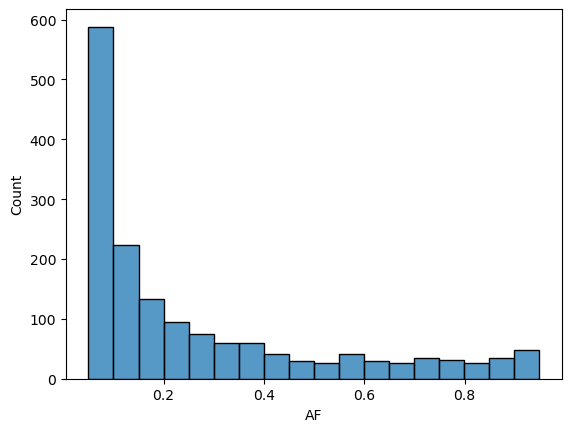

In [135]:
sns.histplot(data=df_lowAF_variants,
             x='AF'
            )

In [128]:
df_lowAF_SNPs_compare.Difference.median(), df_lowAF_SNPs_compare.Difference.mean()

(2.0, 2.7371273712737128)

In [129]:
df_lowAF_SNPs_compare.Difference.min(), df_lowAF_SNPs_compare.Difference.max()

(0, 14)

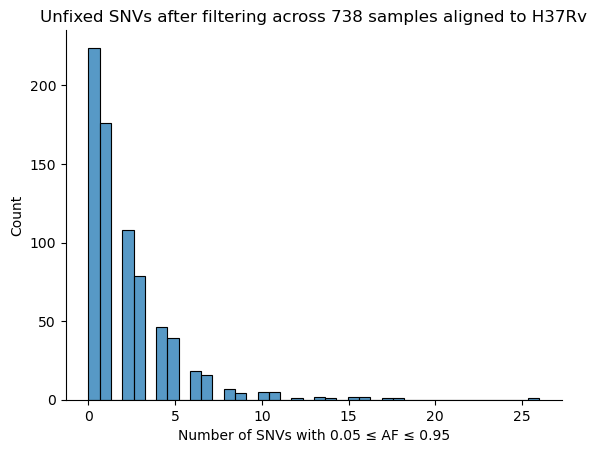

In [120]:
df_plot = df_lowAF_SNPs_compare.query("F2 <= @F2_max")

sns.histplot(data=df_plot,
             x='After'
            )

plt.title(f"Unfixed SNVs after filtering across {df_plot.SampleID.nunique()} samples aligned to H37Rv")
plt.xlabel('Number of SNVs with 0.05 ≤ AF ≤ 0.95')

sns.despine()
plt.savefig("./figures/H37Rv_lowAF_counts_final_dist.svg", bbox_inches='tight')

In [121]:
st.ks_2samp(df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max")['NumSNPs'],
            df_lowAF_SNPs_compare.query("F2 <= @F2_max")['Before']
           )

KstestResult(statistic=0.4241349971639251, pvalue=3.908807274241625e-23, statistic_location=2, statistic_sign=1)

In [122]:
st.ks_2samp(df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max")['NumSNPs'],
            df_lowAF_SNPs_compare.query("F2 <= @F2_max")['After']
           )

KstestResult(statistic=0.04189512825360812, pvalue=0.9569623208726006, statistic_location=0, statistic_sign=-1)

In [123]:
len(df_lowAF_SNPs_compare.query("After==0")), len(df_lowAF_SNPs_compare.query("After==0")) / len(df_lowAF_SNPs_compare)

(224, 0.3035230352303523)

In [125]:
len(df_lowAF_SNPs_compare.query("Before==0")), len(df_lowAF_SNPs_compare.query("Before==0")) / len(df_lowAF_SNPs_compare)

(38, 0.051490514905149054)

In [126]:
len(df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max & NumSNPs==0")), len(df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max & NumSNPs==0")) / len(df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max"))

(45, 0.2616279069767442)

In [72]:
df_lowAF_variants.GENE.value_counts().head(10)

GENE
sugI       42
Rv2690c    19
devR       18
devS       18
phoR       15
subI       10
Rv1830      9
ceoB        9
Rv3220c     8
dosT        8
Name: count, dtype: int64

In [322]:
df_lowAF_variants.dropna(subset='HGVS_P').query("HGVS_P.str.contains('p.Pro7') & GENE=='sugI'")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,NEG_COV_RATIO,POS_COV_RATIO,predicted,pred_class,Sampling_Week,SNP,Region,Variant_Type,REF_AA,ALT_AA
40,3717108,C,A,3.436120e+03,sugI,c.19C>A,p.Pro7Thr,1.0,259,259.0,...,0.032327,0.000000,0.981509,1.0,1,3717108_C_A,sugI,Missense,Pro,Thr
70,3717108,C,A,3.679100e+03,sugI,c.19C>A,p.Pro7Thr,1.0,299,299.0,...,0.020830,0.000000,0.787622,1.0,1,3717108_C_A,sugI,Missense,Pro,Thr
191,3717108,C,A,0.000000e+00,sugI,c.19C>A,p.Pro7Thr,1.0,338,338.0,...,0.056455,0.000000,0.972729,1.0,7,3717108_C_A,sugI,Missense,Pro,Thr
551,3717109,C,A,1.727320e+03,sugI,c.20C>A,p.Pro7His,1.0,258,258.0,...,0.026617,0.000000,0.948647,1.0,1,3717109_C_A,sugI,Missense,Pro,His
724,3717108,C,A,7.027610e-14,sugI,c.19C>A,p.Pro7Thr,1.0,227,227.0,...,0.043211,0.000000,0.904896,1.0,1,3717108_C_A,sugI,Missense,Pro,Thr
776,3717109,C,A,2.155280e-13,sugI,c.20C>A,p.Pro7His,1.0,291,291.0,...,0.000000,0.010925,0.938662,1.0,1,3717109_C_A,sugI,Missense,Pro,His
912,3717108,C,A,9.221620e-15,sugI,c.19C>A,p.Pro7Thr,1.0,218,218.0,...,0.076736,0.000000,0.966705,1.0,8,3717108_C_A,sugI,Missense,Pro,Thr
1312,3717109,C,A,4.496200e-14,sugI,c.20C>A,p.Pro7His,1.0,273,273.0,...,0.038977,0.000000,0.996637,1.0,1,3717109_C_A,sugI,Missense,Pro,His
1391,3717109,C,A,1.677930e-13,sugI,c.20C>A,p.Pro7His,1.0,425,425.0,...,0.000000,0.014189,0.998478,1.0,6,3717109_C_A,sugI,Missense,Pro,His
1544,3717108,C,A,6.762140e+01,sugI,c.19C>A,p.Pro7Thr,1.0,285,285.0,...,0.051966,0.000000,0.989352,1.0,6,3717108_C_A,sugI,Missense,Pro,Thr


# 5. How many Ground Truth Variants could not be Transferred to H37Rv Coordinates?

Those in IS6110 elements will not be able to be transferred, so leave as is. 

Right now, there is one real variant that could not be transferred: 3717219 (sugI) in MFS-160. I don't know why it wasn't transferred. 

But there is no longitudinal sampling for this pid, so it's not a huge deal, and it's detected when aligning Illumina reads to H37Rv and the LMM predicts it as a real variant, so the signal is good. paftools.js liftover just fails.

In [7]:
def get_id_from_gtf_attribute(attr_string):
    """
    Extract the value of the ID field from a GTF/GFF attributes string.

    Example:
    attr_string = "ID=gene-Rv3324c;Dbxref=GeneID:887981;Name=moaC3;..."
    returns "gene-Rv3324c"
    """
    # Split by semicolon
    fields = attr_string.split(";")
    
    # Iterate through key=value pairs
    for f in fields:
        f = f.strip()
        if f.startswith("ID="):
            return f.split("=", 1)[1]  # split only on first '='
    
    # If no ID field found, return None
    return None

In [5]:
df_transferred_variants = pd.DataFrame(columns = ['SampleID', 'NumSNPs', 'NumSNPsTransferred'])

for i, sample in enumerate(os.listdir(personal_ref_dir)):
    
    personal_genome_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.bed", sep='\t').query("REF.str.len() == ALT.str.len()").drop_duplicates(subset=['POS', 'REF', 'ALT'])

    H37Rv_transferred_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.bed", sep='\t', header=None, names=['H37Rv_CHROM', 'H37Rv_BEG', 'H37Rv_END', 'Orig_Variant', 'Score', 'Sense'])
    
    if len(H37Rv_transferred_variants) > 0:
        H37Rv_transferred_variants[['CHROM', 'BEG', 'END']] = H37Rv_transferred_variants['Orig_Variant'].str.rsplit('_', n=2, expand=True)
        H37Rv_transferred_variants[['BEG', 'END']] = H37Rv_transferred_variants[['BEG', 'END']].astype(int)
        
        combined_variants = personal_genome_variants.merge(H37Rv_transferred_variants, on=['CHROM', 'BEG', 'END']).drop_duplicates(subset=['POS', 'REF', 'ALT'])
        num_transferred = len(combined_variants)
    else:
        num_transferred = 0
            
    df_transferred_variants.loc[i, :] = [sample, len(personal_genome_variants), num_transferred]
    
df_transferred_variants = df_transferred_variants.merge(df_trust_patients[['pid', 'SampleID', 'F2', 'Coll2014']], on='SampleID', how='left')
assert sum(pd.isnull(df_transferred_variants['pid'])) == 0

In [8]:
search_samples = df_transferred_variants.query("F2 <= @F2_max & NumSNPs != NumSNPsTransferred").SampleID.values

for sample in search_samples:

    personal_genome_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.bed", sep='\t')#.query("REF.str.len() == ALT.str.len()")

    H37Rv_transferred_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.bed", sep='\t', header=None, names=['H37Rv_CHROM', 'H37Rv_BEG', 'H37Rv_END', 'Orig_Variant', 'Score', 'Sense'])

    if len(H37Rv_transferred_variants) > 0:

        H37Rv_transferred_variants[['CHROM', 'BEG', 'END']] = H37Rv_transferred_variants['Orig_Variant'].str.rsplit('_', n=2, expand=True)
        H37Rv_transferred_variants[['BEG', 'END']] = H37Rv_transferred_variants[['BEG', 'END']].astype(int)

        combined_variants = personal_genome_variants.merge(H37Rv_transferred_variants, on=['CHROM', 'BEG', 'END']).drop_duplicates(subset=['POS', 'REF', 'ALT'])
        num_transferred = len(combined_variants)

        missed_pos = list(set(personal_genome_variants.POS) - set(combined_variants.POS))

        # see if the variant was found when aligning to H37Rv. If it was, then we have a problem that we can fix. If it wasn't, then the region is just too different for paftools liftover to transfer it
        df_H37Rv_variants = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/lowAF_SNPs.csv")
        
        liftoff_gtf = pd.read_csv(f"{personal_ref_dir}/{sample}/assembly/H37Rv.liftoff.gff_polished", sep='\t', header=None, comment='#',
                                  names=['Chrom', 'Source', 'Feature', 'Start', 'End', 'Score', 'Sense', 'Score2', 'Attribute']
                                 )
        
#         df_IS6110_elements = pd.read_csv(f"{personal_ref_dir}/{sample}/IS6110/{sample}.sam", header=None, sep='\t')
        
#         IS6110_pos = []
        
#         # IS6110 element is 1,355 bp long
#         for i, row in df_IS6110_elements.iterrows():
#             IS6110_pos += list(np.arange(row[3], row[3] + 1355))

        for pos in missed_pos:
            # min_distance = np.min(np.abs(np.array([pos]) - np.array(IS6110_pos)))
            AF = personal_genome_variants.query("POS==@pos").get('AF').values[0]
            # print(f"{sample} has a missed position, {pos} with AF = {np.round(AF, 4)} within {min_distance} bp of an IS6110 element")
            print(f"{sample} has a missed position, {pos} with AF = {np.round(AF, 4)}")
            
            within_gene = liftoff_gtf.query("Feature=='gene' & Start <= @pos & End >= @pos")
            
            if len(within_gene) > 0:
                gene = get_id_from_gtf_attribute(within_gene.Attribute.values[-1]).split('-')[-1]
                print(f"    Within {gene}")
            else:
                upstream_gene = get_id_from_gtf_attribute(liftoff_gtf.query("Feature=='gene' & Start <= @pos").Attribute.values[-1]).split('-')[-1]
                downstream_gene = get_id_from_gtf_attribute(liftoff_gtf.query("End >= @pos").Attribute.values[0]).split('-')[-1]
                print(f"    {upstream_gene}-{downstream_gene}")

MFS-160 has a missed position, 3725173 with AF = 0.1342
    Within Rv3331
MFS-26 has a missed position, 3719445 with AF = 0.244
    Rv3324c-Rv3327
MFS-321 has a missed position, 3711316 with AF = 0.3899
    Rv3324c-Rv3327
MFS-322 has a missed position, 3711316 with AF = 0.4315
    Rv3324c-Rv3327
MFS-4 has a missed position, 3708237 with AF = 0.2005
    Rv3324c-Rv3327
MFS-41 has a missed position, 3950774 with AF = 0.0726
    Within Rv3511
MFS-754 has a missed position, 3889905 with AF = 0.3983
    Within Rv3478
MFS-754 has a missed position, 3889917 with AF = 0.425
    Within Rv3478
MFS-754 has a missed position, 3889918 with AF = 0.425
    Within Rv3478


# F2 for Longitudinal Samples

In [72]:
df_longitudinal_pids = pd.read_csv(f"{TRUST_data_dir}/longitudinal_pids_WGS_data.csv")
print(f"{df_longitudinal_pids.pid.nunique()} pids")

pids_with_low_F2 = pd.DataFrame(df_longitudinal_pids.query("F2 <= @F2_max").groupby('pid')['SampleID'].nunique()).query("SampleID > 1").index.values

# # additionally require pids to have had the EXACT same lineage
pids_with_same_lineage = pd.DataFrame(df_longitudinal_pids.groupby('pid')['mix_phylotypes'].nunique()).query("mix_phylotypes == 1").index.values
pids_with_same_lineage = np.unique(list(pids_with_same_lineage))

pids_with_same_lineage_and_low_F2 = list(set(pids_with_low_F2).intersection(pids_with_same_lineage))
print(f"{len(pids_with_same_lineage_and_low_F2)} pids have F2 ≤ {F2_max} and matching lineages between timepoints")

df_longitudinal_pids['Sampling_Interval'] = df_longitudinal_pids.groupby('pid')['Sampling_Week'].transform(lambda x: np.max(x) - np.min(x))
print(f"    Sampling interval: median = {df_longitudinal_pids.Sampling_Interval.median()}, mean = {df_longitudinal_pids.Sampling_Interval.mean()}")

325 pids
285 pids have F2 ≤ 0.03 and matching lineages between timepoints
    Sampling interval: median = 6.0, mean = 5.483076923076923


In [5]:
df_longitudinal_pids.sort_values(['pid', 'Sampling_Week'], ascending=True).drop_duplicates(subset='pid', keep='first').Sampling_Week.max()

2

In [6]:
df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2").drop_duplicates('pid').Lineage.value_counts()

Lineage
2    149
4    121
3     15
Name: count, dtype: int64

In [7]:
# df_longitudinal_pids['Major_Lineage'] = np.nan
# df_longitudinal_pids['Major_Lineage_Prop'] = np.nan
# df_longitudinal_pids['Minor_Lineage'] = np.nan
# df_longitudinal_pids['Minor_Lineage_Prop'] = np.nan

# for i, row in df_longitudinal_pids.iterrows():
    
#     pid = row['pid']
#     sample = row['SampleID']
    
#     if ',' in row['mix_phylotypes']:
        
#         lineages = row['mix_phylotypes'].split(',')
#         props = np.array(row['mix_props'].split(',')).astype(float)
        
#         major_lineage = lineages[np.argmax(props)]
#         major_prop = np.max(props)
        
#     else:
#         major_lineage = row['mix_phylotypes']
#         major_prop = 1
    
#     df_longitudinal_pids.loc[i, 'Major_Lineage'] = major_lineage
#     df_longitudinal_pids.loc[i, 'Major_Lineage_Prop'] = major_prop
    
#     if ',' in row['mix_phylotypes']:
        
#         second_highest_idx = np.argpartition(props, -2)[-2]
        
#         df_longitudinal_pids.loc[i, 'Minor_Lineage'] = lineages[second_highest_idx]
#         df_longitudinal_pids.loc[i, 'Minor_Lineage_Prop'] = props[second_highest_idx]

# df_longitudinal_pids['Major_Lineage'] = df_longitudinal_pids['Major_Lineage'].fillna(df_longitudinal_pids['Coll2014'])
# df_longitudinal_pids['Major_Lineage_Prop'] = df_longitudinal_pids['Major_Lineage_Prop'].fillna(1)

# df_longitudinal_pids['Major_Minor_Diff'] = df_longitudinal_pids['Major_Lineage_Prop'] - df_longitudinal_pids['Minor_Lineage_Prop']

pids_with_overlap_lineages_2_samples = []

for pid in df_longitudinal_pids.pid.unique():
    
    lineage_1 = df_longitudinal_pids.query("pid==@pid & Paired_Sample_Num==1").mix_phylotypes.values[0].split(',')
    lineage_2 = df_longitudinal_pids.query("pid==@pid & Paired_Sample_Num==2").mix_phylotypes.values[0].split(',')
    
    if len(set(lineage_1).intersection(lineage_2)) > 0:
        pids_with_overlap_lineages_2_samples.append(pid)
        
print(f"{len(pids_with_overlap_lineages_2_samples)}/{df_longitudinal_pids.pid.nunique()} pids have overlapping lineages between timepoints 1 and 2")

df_longitudinal_pids = df_longitudinal_pids.query("pid in @pids_with_overlap_lineages_2_samples").reset_index(drop=True)
print(f"    Sampling interval: median = {df_longitudinal_pids.Sampling_Interval.median()}, mean = {df_longitudinal_pids.Sampling_Interval.mean()}")

310/325 pids have overlapping lineages between timepoints 1 and 2
    Sampling interval: median = 6.0, mean = 5.496774193548387


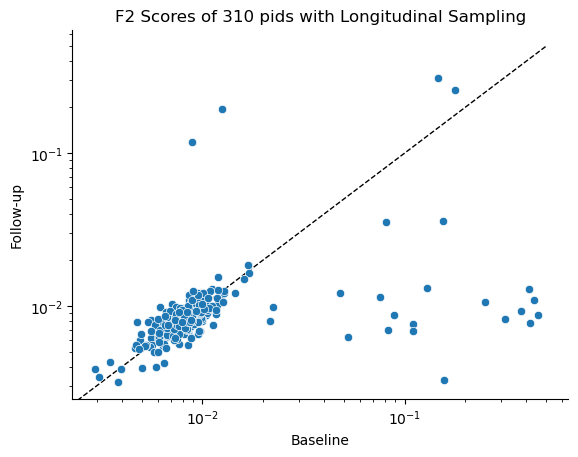

In [8]:
df_F2_longitudinal = df_longitudinal_pids.pivot(index='pid', columns='Paired_Sample_Num', values='F2').reset_index()
df_F2_longitudinal.columns = ['pid', 'Sample1', 'Sample2']
df_F2_longitudinal['F2_Diff'] = df_F2_longitudinal['Sample2'] - df_F2_longitudinal['Sample1']
df_F2_longitudinal['Abs_F2_Diff'] = np.abs(df_F2_longitudinal['F2_Diff'])

sns.scatterplot(data=df_F2_longitudinal,
                x='Sample1',
                y='Sample2',
               )

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Baseline')
plt.ylabel('Follow-up')
plt.title(f'F2 Scores of {df_longitudinal_pids.pid.nunique()} pids with Longitudinal Sampling')

x_vals = np.linspace(0, 0.5, 10)
plt.plot(x_vals, x_vals, color='black', zorder=0, linestyle='--', linewidth=1)

sns.despine()
plt.savefig("./figures/F2_longitudinal.svg", bbox_inches='tight')

In [9]:
st.ttest_rel(df_F2_longitudinal['Sample1'],
             df_F2_longitudinal['Sample2'],
             alternative='greater'
            )

TtestResult(statistic=2.803684700735652, pvalue=0.002685917885121972, df=309)

In [182]:
df_tbtyper_culture = pd.read_csv("~/MtbLongitudinalDiversity/TBtypeR/culture_TBtypeR_results.csv")
df_tbtyper_culture['SampleID'] = df_tbtyper_culture['sample_id'].str.split('.').str[0]

df_tbtyper_culture = df_tbtyper_culture.merge(df_trust_patients[['SampleID', 'pid', 'Original_ID', 'Sampling_Week']])
df_tbtyper_culture['mix_phylotypes'] = df_tbtyper_culture.groupby('sample_id')['mix_phylotype'].transform(lambda x: ','.join(x))

df_tbtyper_culture['mix_prop'] = np.rint(df_tbtyper_culture['mix_prop']*100).astype(int)
df_tbtyper_culture['mix_props'] = df_tbtyper_culture.groupby('sample_id')['mix_prop'].transform(lambda x: ','.join(np.array(x).astype(str)))

df_tbtyper_culture = df_tbtyper_culture.drop_duplicates(subset='sample_id').reset_index(drop=True)

df_tbtyper_culture = df_tbtyper_culture.sort_values(['pid', 'Sampling_Week', 'SampleID']).drop_duplicates(subset='Original_ID', keep='first').reset_index(drop=True)

df_tbtyper_culture['Timepoint'] = df_tbtyper_culture.sort_values(['pid', 'Sampling_Week']).groupby('pid')['SampleID'].cumcount() + 1

df_tbtyper_culture_mixed = df_tbtyper_culture.query("pid in @pids_mixed_infections").pivot(index='pid', columns='Timepoint', values=['mix_phylotypes', 'mix_props', 'Sampling_Week']).reset_index()
df_tbtyper_culture_mixed.columns = df_tbtyper_culture_mixed.columns.droplevel(1)
df_tbtyper_culture_mixed.columns = ['pid', 'mix_phylotypes_1', 'mix_phylotypes_2', 'mix_phylotypes_3', 'mix_props_1', 'mix_props_2', 'mix_props_3', 'week_1', 'week_2', 'week_3']

df_tbtyper_culture_mixed['Major_Prop_1'] = df_tbtyper_culture_mixed['mix_props_1'].transform(lambda x: np.array(x.split(',')).astype(int).max())
df_tbtyper_culture_mixed['Minor_Prop_1'] = df_tbtyper_culture_mixed['mix_props_1'].transform(lambda x: np.array(x.split(',')).astype(int).min())
df_tbtyper_culture_mixed['Major_Prop_2'] = df_tbtyper_culture_mixed['mix_props_2'].transform(lambda x: np.array(x.split(',')).astype(int).max())
df_tbtyper_culture_mixed['Minor_Prop_2'] = df_tbtyper_culture_mixed['mix_props_2'].transform(lambda x: np.array(x.split(',')).astype(int).min())

In [203]:
for i, row in df_tbtyper_culture_mixed.iterrows():
    
    mix_phylotypes_1 = row['mix_phylotypes_1'].split(',')
    mix_props_1 = np.array(row['mix_props_1'].split(',')).astype(int)
    
    mix_phylotypes_2 = row['mix_phylotypes_2'].split(',')
    mix_props_2 = np.array(row['mix_props_2'].split(',')).astype(int)
    
    if len(mix_phylotypes_1) > 1 and len(mix_phylotypes_2) == 1:
        
        major_lineage = mix_phylotypes_1[np.argmax(mix_props_1)]
        minor_lineage = mix_phylotypes_1[np.argmin(mix_props_1)]
        
        if major_lineage == mix_phylotypes_2[0]:
            group = 'Major Increase'
        else:
            group = 'Minor Increase'
            
    elif len(mix_phylotypes_1) == 1 and len(mix_phylotypes_2) > 1:
        
        group = 'Minor Increase'
        
    elif len(mix_phylotypes_1) > 1 and len(mix_phylotypes_2) > 1:
        
        group = 'Persistent Mixed'
        
    df_tbtyper_culture_mixed.loc[i, 'Group'] = group

In [184]:
df_tbtyper_culture_expanded = pd.read_csv("~/MtbLongitudinalDiversity/TBtypeR/culture_TBtypeR_results.csv")
df_tbtyper_culture_expanded['SampleID'] = df_tbtyper_culture_expanded['sample_id'].str.split('.').str[0]

df_tbtyper_culture_expanded = df_tbtyper_culture_expanded.merge(df_trust_patients[['SampleID', 'pid', 'Original_ID', 'Sampling_Week']])
df_tbtyper_culture_expanded['mix_prop'] = np.rint(df_tbtyper_culture_expanded['mix_prop']*100).astype(int)

df_tbtyper_culture_expanded = df_tbtyper_culture_expanded.merge(df_tbtyper_culture[['Original_ID', 'Timepoint']], how='left')

In [185]:
pids_mixed_infections = df_longitudinal_pids.query("mix_phylotypes.str.contains(',')").pid.unique()
len(pids_mixed_infections)

25

In [204]:
df_tbtyper_culture_plot = df_tbtyper_culture_expanded.query("pid in @pids_mixed_infections")[['pid', 'SampleID', 'mix_phylotype', 'mix_prop', 'Sampling_Week', 'Timepoint']].sort_values(['pid', 'Sampling_Week']).reset_index(drop=True)

df_tbtyper_culture_plot = df_tbtyper_culture_plot.merge(df_tbtyper_culture_mixed[['pid', 'Group']])

df_wide = df_tbtyper_culture_plot.query("Timepoint <= 2").pivot_table(
    index=['pid', 'Timepoint'],
    columns='mix_phylotype',
    values='mix_prop',
    fill_value=0
)
# for i, row in df_tbtyper_culture_mixed.iterrows():
    
#     pid = row['pid']
    
#     single_pid_lineages = df_tbtyper_culture_mixed.query("pid==@pid").mix_phylotype.unique()
    
#     if len(df_tbtyper_culture_mixed.query("pid==@pid @"))

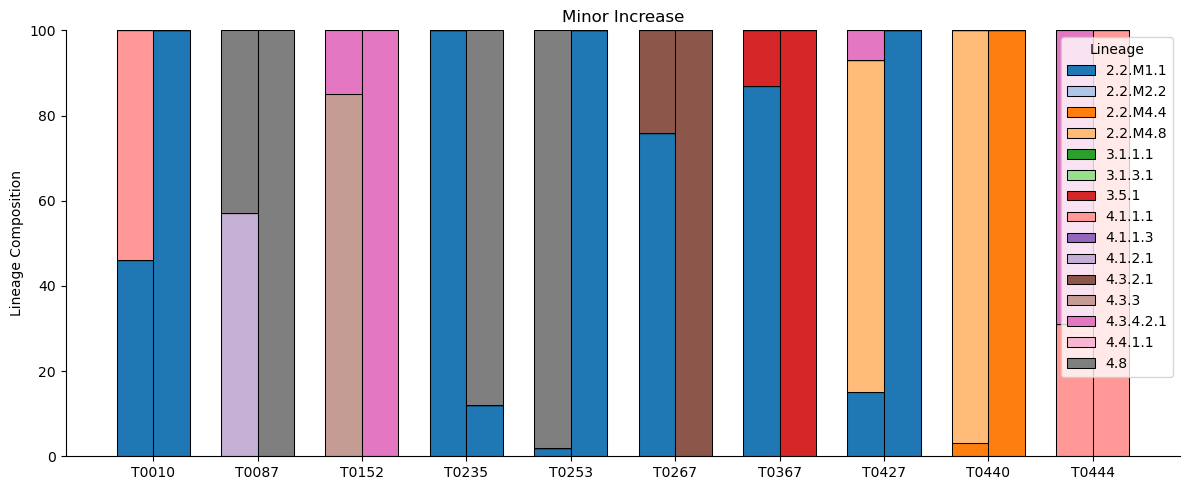

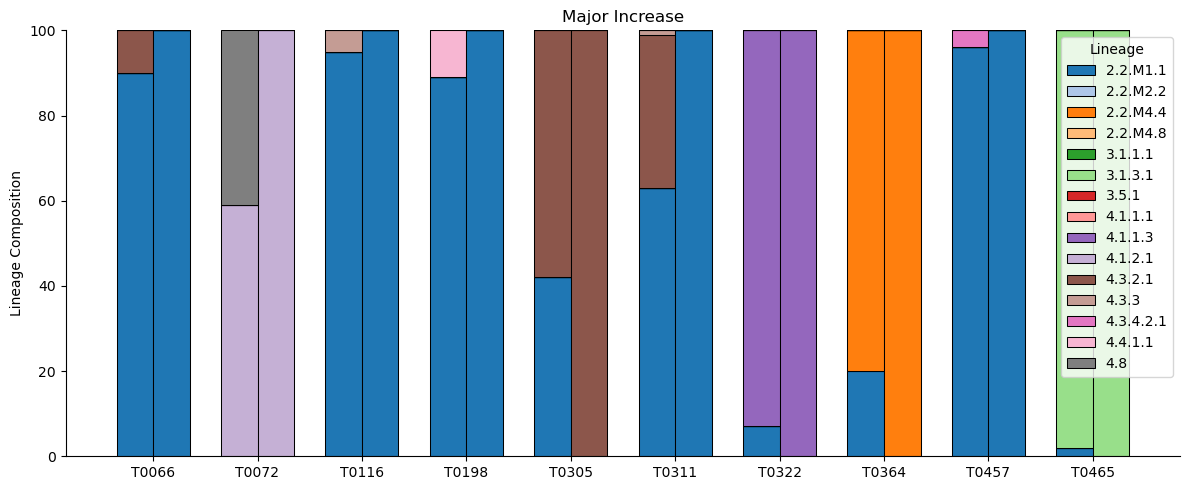

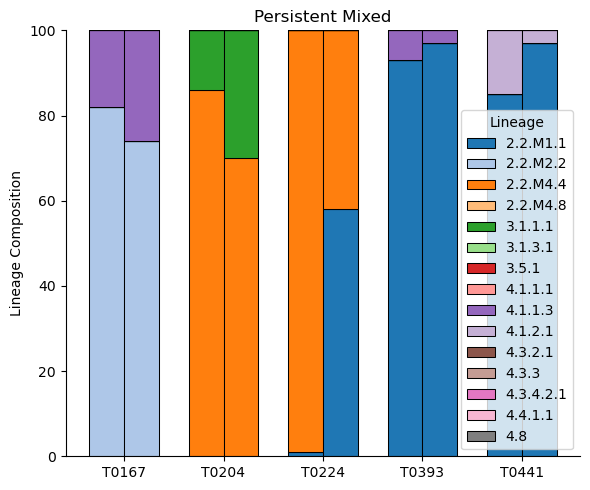

In [208]:
for group in df_tbtyper_culture_plot.Group.unique():
    
    pids_in_group = df_tbtyper_culture_plot.query("Group==@group").pid.unique()
    
    df_single_wide = df_wide.loc[pids_in_group]

    fig, ax = plt.subplots(figsize=(int(len(pids_in_group)*1.25),5))

    # create x positions
    pids = df_single_wide.index.get_level_values('pid').unique()
    samples = df_single_wide.index.get_level_values('Timepoint').unique()

    color_dict = dict(zip(df_single_wide.columns, sns.color_palette('tab20').as_hex()[:df_single_wide.shape[1]]))

    bar_width = 0.35
    x = range(len(pids))

    seen_labels = set()

    for i, sample in enumerate(samples):
        subset = df_single_wide.xs(sample, level='Timepoint')
        bottom = None

        for lineage in df_single_wide.columns:
            values = subset[lineage].values

            ax.bar(
                [pos + i*bar_width for pos in x],
                values,
                bar_width,
                bottom=bottom,
                color=color_dict[lineage],
                edgecolor='black',
                linewidth=0.75,
                label=lineage if lineage not in seen_labels else None,
            )

            if bottom is None:
                bottom = values
            else:
                bottom += values

            seen_labels.add(lineage)

    ax.set_xticks([pos + bar_width/2 for pos in x])
    ax.set_xticklabels(pids)
    ax.set_ylabel('Lineage Composition')
    ax.set_title(group)
    ax.legend(title='Lineage')

    plt.tight_layout()
    sns.despine()
    plt.savefig(f"figures/{group}_mixed_lineage_changes.svg", bbox_inches='tight')

In [202]:
df_tbtyper_culture_mixed.query("Group=='Additional lineage'")

,pid,mix_phylotypes_1,mix_phylotypes_2,mix_phylotypes_3,mix_props_1,mix_props_2,mix_props_3,week_1,week_2,week_3,Major_Prop_1,Minor_Prop_1,Major_Prop_2,Minor_Prop_2,Group
10,T0235,2.2.M1.1,"4.8,2.2.M1.1",NaN,100,"88,12",NaN,1,5,NaN,100,100,88,12,Additional lineage


,pid,Group
0,T0010,Major Lost
1,T0066,Minor Lost
2,T0072,Minor Lost
3,T0087,Major Lost
4,T0116,Minor Lost
5,T0152,Major Lost
6,T0167,Persistent mixed
7,T0198,Minor Lost
8,T0204,Persistent mixed
9,T0224,Persistent mixed


In [53]:
df_tbtyper_culture_mixed.Group.value_counts()

Group
Minor Lost            10
Major Lost             9
Persistent mixed       5
Additional lineage     1
Name: count, dtype: int64

In [74]:
df_tbtyper_culture_mixed.to_csv("~/tbtyper_results.csv", index=False)

In [75]:
df_tbtyper_culture_mixed

,pid,mix_phylotypes_1,mix_phylotypes_2,mix_phylotypes_3,mix_props_1,mix_props_2,mix_props_3,week_1,week_2,week_3,Major_Prop_1,Minor_Prop_1,Major_Prop_2,Minor_Prop_2,Group
0,T0010,"4.1.1.1,2.2.M1.1",2.2.M1.1,NaN,"54,46",100,NaN,1,8,NaN,54,46,100,100,Major Lost
1,T0066,"2.2.M1.1,4.3.2.1",2.2.M1.1,NaN,"90,10",100,NaN,1,8,NaN,90,10,100,100,Minor Lost
2,T0072,"4.1.2.1,4.8",4.1.2.1,NaN,"59,41",100,NaN,1,6,NaN,59,41,100,100,Minor Lost
3,T0087,"4.1.2.1,4.8",4.8,NaN,"57,43",100,NaN,1,8,NaN,57,43,100,100,Major Lost
4,T0116,"2.2.M1.1,4.3.3",2.2.M1.1,NaN,"95,5",100,NaN,1,6,NaN,95,5,100,100,Minor Lost
5,T0152,"4.3.3,4.3.4.2.1",4.3.4.2.1,NaN,"85,15",100,NaN,1,4,NaN,85,15,100,100,Major Lost
6,T0167,"2.2.M2.2,4.1.1.3","2.2.M2.2,4.1.1.3",NaN,"82,18","74,26",NaN,1,4,NaN,82,18,74,26,Persistent mixed
7,T0198,"2.2.M1.1,4.4.1.1",2.2.M1.1,NaN,"89,11",100,NaN,2,7,NaN,89,11,100,100,Minor Lost
8,T0204,"2.2.M4.4,3.1.1.1","2.2.M4.4,3.1.1.1",2.2.M4.4,"86,14","70,30",100,1,8,20,86,14,70,30,Persistent mixed
9,T0224,"2.2.M4.4,2.2.M1.1","2.2.M1.1,2.2.M4.4",NaN,"99,1","58,42",NaN,1,8,NaN,99,1,58,42,Persistent mixed


Text(0.5, 1.0, 'Longitudinal Changes in Lineage Proportions')

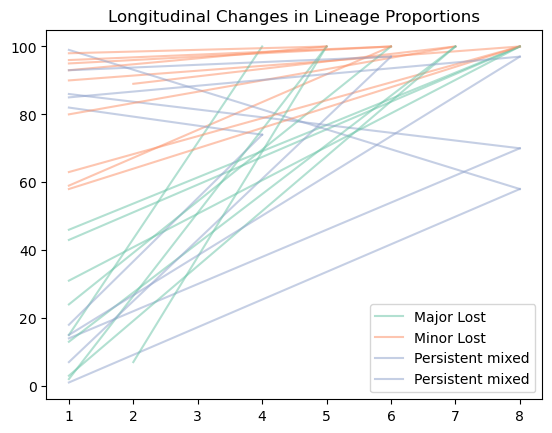

In [72]:
seen = set()

color_dict = dict(zip(df_tbtyper_culture_mixed.Group.unique(), list(sns.color_palette('Set2').as_hex())[:df_tbtyper_culture_mixed.Group.nunique()]))

for _, row in df_tbtyper_culture_mixed.iterrows():
    
    week_1, week_2, group = row['week_1'], row['week_2'], row['Group']
    
    label = row['Group'] if row['Group'] not in seen else None
    
    # plot each lineage at each timepoint for each pid if there is more than one lineage
    if group == 'Major Lost':
    
        plt.plot([int(week_1), int(week_2)], 
                 [row['Minor_Prop_1'], row['Minor_Prop_2']],
                 color=color_dict[group],
                 alpha=0.5,
                 linewidth=1.5,
                 label=label
                )
        
    elif group == 'Minor Lost':
    
        plt.plot([int(week_1), int(week_2)], 
                 [row['Major_Prop_1'], row['Major_Prop_2']],
                 color=color_dict[group],
                 alpha=0.5,
                 linewidth=1.5,
                 label=label
                )
        
        
    elif group == 'Persistent mixed':
    
        plt.plot([int(week_1), int(week_2)], 
                 [row['Major_Prop_1'], row['Major_Prop_2']],
                 color=color_dict[group],
                 alpha=0.5,
                 linewidth=1.5,
                 label=label
                )
        
        plt.plot([int(week_1), int(week_2)], 
                 [row['Minor_Prop_1'], row['Major_Prop_2']],
                 color=color_dict[group],
                 alpha=0.5,
                 linewidth=1.5,
                 label=label
                )
        
#     elif group == 'Minor Lost':
    
#         plt.plot([int(week_1), int(week_2)], 
#                  [row['Major_Prop_1'], row['Major_Prop_2']],
#                  color=color_dict[group],
#                  alpha=0.5,
#                  linewidth=1.5,
#                  label=label
#                 )
    
    seen.add(row['Group'])
    
plt.legend()

# --- 5. Format axes ---
plt.title(f"Longitudinal Changes in Lineage Proportions")

In [58]:
week_1, week_2, group

(1, 5, 'Minor Lost')

In [56]:
df_tbtyper_culture_mixed

,pid,mix_phylotypes_1,mix_phylotypes_2,mix_phylotypes_3,mix_props_1,mix_props_2,mix_props_3,week_1,week_2,week_3,Major_Prop_1,Minor_Prop_1,Major_Prop_2,Minor_Prop_2,Group
0,T0010,"4.1.1.1,2.2.M1.1",2.2.M1.1,NaN,"54,46",100,NaN,1,8,NaN,54,46,100,100,Major Lost
1,T0066,"2.2.M1.1,4.3.2.1",2.2.M1.1,NaN,"90,10",100,NaN,1,8,NaN,90,10,100,100,Minor Lost
2,T0072,"4.1.2.1,4.8",4.1.2.1,NaN,"59,41",100,NaN,1,6,NaN,59,41,100,100,Minor Lost
3,T0087,"4.1.2.1,4.8",4.8,NaN,"57,43",100,NaN,1,8,NaN,57,43,100,100,Major Lost
4,T0116,"2.2.M1.1,4.3.3",2.2.M1.1,NaN,"95,5",100,NaN,1,6,NaN,95,5,100,100,Minor Lost
5,T0152,"4.3.3,4.3.4.2.1",4.3.4.2.1,NaN,"85,15",100,NaN,1,4,NaN,85,15,100,100,Major Lost
6,T0167,"2.2.M2.2,4.1.1.3","2.2.M2.2,4.1.1.3",NaN,"82,18","74,26",NaN,1,4,NaN,82,18,74,26,Persistent mixed
7,T0198,"2.2.M1.1,4.4.1.1",2.2.M1.1,NaN,"89,11",100,NaN,2,7,NaN,89,11,100,100,Minor Lost
8,T0204,"2.2.M4.4,3.1.1.1","2.2.M4.4,3.1.1.1",2.2.M4.4,"86,14","70,30",100,1,8,20,86,14,70,30,Persistent mixed
9,T0224,"2.2.M4.4,2.2.M1.1","2.2.M1.1,2.2.M4.4",NaN,"99,1","58,42",NaN,1,8,NaN,99,1,58,42,Persistent mixed


In [19]:
major_lineage, minor_lineage

('3.1.3.1', '2.2.M1.1')

In [28]:
pids_decrease_F2 = df_F2_longitudinal.query("Sample1 > Sample2 & Sample1 > @F2_max").pid.unique()

major_lineage_remaining_FU = []

for pid in pids_decrease_F2:
    
    major_lineage_1 = df_longitudinal_pids.query("pid==@pid").sort_values('Sampling_Week').Major_Lineage.values[0]
    major_lineage_2 = df_longitudinal_pids.query("pid==@pid").sort_values('Sampling_Week').Major_Lineage.values[-1]
    
    if major_lineage_1 == major_lineage_2:
        major_lineage_remaining_FU.append(pid)
        
len(major_lineage_remaining_FU), len(pids_decrease_F2)

AttributeError: 'DataFrame' object has no attribute 'Major_Lineage'

In [29]:
df_tbtyper_DS_culture_matched.query("pid in ['T0204', 'T0167']")

NameError: name 'df_tbtyper_DS_culture_matched' is not defined

In [130]:
df_tbtyper_DS_culture_matched.query("pid in @pids_decrease_F2")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,Num_Culture_Samples,Paired_Culture_Sample,Sample,mix_phylotypes,mix_props,n_phy,defaultParams,Median_Depth,Exact_Match
15,MFS-39,"2.2.M1.1,4.3.2.1","0.8965,0.1035",2,1,T0066,S0066-01,1,0.110925,2.2.1.1,2.0,1,S0066-01,"2.2.M1.1,2.2.M4.4,4.3.2.1","0.4116,0.4728,0.1156",3.0,1.0,360.0,1.0
96,MFS-313,"2.2.M1.1,4.3.2.1","0.4235,0.5765",2,1,T0305,S0305-01,1,0.436810,"4.3.2.1,2.2.1.1",2.0,1,S0305-01,"2.2.M1.1,4.3.2.1","0.0441,0.9559",2.0,1.0,55.0,1.0
100,MFS-198,"2.2.M1.1,4.1.1.3","0.0645,0.9355",2,1,T0322,S0322-01,1,0.075920,4.1.1.3,2.0,1,S0322-01,"2.2.M1.1,4.1.1.1,4.1.1.3","0.1568,0.0264,0.8168",3.0,1.0,156.0,1.0
119,MFS-456,"2.2.M1.1,3.5.1","0.8739,0.1261",2,1,T0367,S0367-01,1,0.130840,2.2.1.1,2.0,1,S0367-01,"2.2.M1.1,2.2.M6,3.5.1","0.5657,0.0283,0.406",3.0,1.0,195.0,1.0
124,MFS-485,"2.2.M1.1,4.1.1.3","0.926,0.074",2,1,T0393,S0393-01,1,0.079214,2.2.1.1,2.0,1,S0393-01,"2.2.M1.1,4.1.1.3","0.5174,0.4826",2.0,1.0,568.0,1.0


In [127]:
df_tbtyper_DS_culture_matched.query("Sampling_Week > 2")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,Num_Culture_Samples,Paired_Culture_Sample,Sample,mix_phylotypes,mix_props,n_phy,defaultParams,Median_Depth,Exact_Match
48,MFS-756,2.2.M4.4,1.0,1,1,T0194,S0194-03,3,0.012164,2.2.1,1.0,1,S0194-01,"2.2.M4.4,4.1.1.3,4.3.2.1","0.4558,0.106,0.4382",3.0,0.0,12.0,1.0
69,MFS-173,2.2.M1.1,1.0,1,1,T0256,S0256-08,8,0.011113,2.2.1.1,2.0,2,S0256-08,2.2.M1.1,1.0,1.0,1.0,63.0,1.0
71,MFS-175,4.1.1.1,1.0,1,1,T0257,S0257-07,7,0.008737,4.1.1.1,2.0,2,S0257-07,4.1.1.1,1.0,1.0,1.0,298.0,1.0
78,MFS-279,2.2.M1.4,1.0,1,1,T0272,S0272-09,9,0.009560,2.2.1,2.0,2,S0272-09,2.2.M1.4,1.0,1.0,1.0,23.0,1.0
80,MFS-273,4.1.1.2,1.0,1,1,T0273,S0273-05,5,0.024653,4.1.1.2,2.0,2,S0273-05,"4.1.1.1,4.1.1.2","0.1194,0.8806",2.0,1.0,41.0,1.0
83,MFS-322,2.2.M4.4,1.0,1,1,T0276,S0276-08,8,0.013765,2.2.1,2.0,2,S0276-07,2.2.M4.4,1.0,1.0,1.0,32.0,1.0
85,MFS-297,4.3.3,1.0,1,1,T0278,S0278-06,6,0.010999,4.3.3,2.0,2,S0278-06,"2.2.M4.4,4.1.1.1,4.3.3","0.1845,0.5209,0.2946",3.0,0.0,12.0,1.0
87,MFS-299,4.3.2.1,1.0,1,1,T0279,S0279-06,6,0.012527,4.3.2.1,2.0,2,S0279-06,"2.2.M2,4.1.1.1,4.3.2.1","0.2102,0.6217,0.1681",3.0,0.0,13.0,1.0
90,MFS-326,2.2.M1.1,1.0,1,1,T0284,S0284-07,7,0.013818,2.2.1.1,2.0,2,S0284-07,2.2.M1.1,1.0,1.0,1.0,20.0,1.0
94,MFS-309,4.1.2,1.0,1,1,T0291,S0291-09,9,0.021034,4.1.2,2.0,2,S0291-09,"4.1.1.1,4.1.2","0.1459,0.8541",2.0,0.0,13.0,1.0


In [103]:
df_longitudinal_pids.query("pid in @pids_decrease_F2 & pid not in @major_lineage_remaining_FU")[['pid', 'SampleID', 'Sampling_Week', 'mix_phylotypes', 'mix_props', 'F2', 'Major_Lineage', 'Major_Lineage_Prop', 'Minor_Lineage', 'Minor_Lineage_Prop']]

,pid,SampleID,Sampling_Week,mix_phylotypes,mix_props,F2,Major_Lineage,Major_Lineage_Prop,Minor_Lineage,Minor_Lineage_Prop
12,T0010,MFS-336,1,"4.1.1.1,2.2.M1.1","0.5416,0.4584",0.459022,4.1.1.1,0.5416,2.2.M1.1,0.4584
13,T0010,MFS-337,8,2.2.M1.1,1.0,0.008737,2.2.M1.1,1.0000,NaN,NaN
122,T0087,MFS-353,1,"4.1.2.1,4.8","0.5709,0.4291",0.418572,4.1.2.1,0.5709,4.8,0.4291
123,T0087,MFS-354,8,4.8,1.0,0.007705,4.8,1.0000,NaN,NaN
198,T0152,MFS-608,1,"4.3.3,4.3.4.2.1","0.8456,0.1544",0.156765,4.3.3,0.8456,4.3.4.2.1,0.1544
199,T0152,MFS-609,4,4.3.4.2.1,1.0,0.003265,4.3.4.2.1,1.0000,NaN,NaN
346,T0267,MFS-270,1,"2.2.M1.1,4.3.2.1","0.7595,0.2405",0.250045,2.2.M1.1,0.7595,4.3.2.1,0.2405
347,T0267,MFS-280,6,4.3.2.1,1.0,0.010598,4.3.2.1,1.0000,NaN,NaN
476,T0367,MFS-456,1,"2.2.M1.1,3.5.1","0.8734,0.1266",0.128377,2.2.M1.1,0.8734,3.5.1,0.1266
477,T0367,MFS-457,7,3.5.1,1.0,0.013176,3.5.1,1.0000,NaN,NaN


In [125]:
df_longitudinal_pids.query("pid in @pids_decrease_F2 & pid not in @major_lineage_remaining_FU")[['pid', 'SampleID', 'Sampling_Week', 'Coll2014', 'F2', 'Major_Lineage', 'Major_Lineage_Prop', 'Minor_Lineage', 'Minor_Lineage_Prop']].drop_duplicates('pid', keep='first').Major_Lineage.value_counts()

Major_Lineage
2.2.M1.1     2
4.1.1.1      1
4.1.2.1      1
4.3.3        1
2.2.M4.8     1
4.3.4.2.1    1
Name: count, dtype: int64

In [136]:
df_longitudinal_pids.query("pid in @pids_decrease_F2 & pid in @major_lineage_remaining_FU")[['pid', 'Sampling_Week', 'Coll2014', 'F2', 'Major_Lineage', 'Major_Lineage_Prop', 'Minor_Lineage', 'Minor_Lineage_Prop']].drop_duplicates('pid', keep='first').Major_Lineage_Prop.mean()

0.783450373857154

In [139]:
df_longitudinal_pids.query("pid in @pids_decrease_F2 & pid in @major_lineage_remaining_FU")[['pid', 'Sampling_Week', 'Coll2014', 'F2', 'Major_Lineage', 'Major_Lineage_Prop', 'Minor_Lineage', 'Minor_Lineage_Prop']].drop_duplicates('pid', keep='first').Major_Lineage.value_counts()

Major_Lineage
2.2.1.1    9
4.1.2.1    1
4.3.2.1    1
4.1.1.3    1
Name: count, dtype: int64